# Example-15: Virtual twiss

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# In this example twiss parameters (or normalization matrices) are estimated at virtual locations
# Given a set of virtual locations, several methods to estimate twiss parameters are considered

# Phase at virtual locations can be computed using model phase advance between a range of monitors (where phase can be measured) and a selected virtual location
# Virtual phase can be also estimated from interpolation

# Given virtual phase, (uncoupled) twiss parameters can be estimated using phase data
# Note, virtual phase accuracy can be poor if model is significantly off
# Here we assume model to be close to real lattice

# Given twiss parameters (or normalization matrices), twiss at virtual locations can be estimated by propagation
# In this case model transport is used to propagate twiss from  monitor (or range of monitors) to a virtual location
# W(V) = T(M, V) W(M) T'(M, V)
# W(M) is a twiss matrix at a monitor (can be constracted from normalization matrix)

# Another options is to propagate normalization matrix using virtual phase
# N(V) = T(M, V) N(M) R^-1(M, V)
# In this case phase advance is fixed

# Twiss at virtual locations can be also estimated using virtual trajectories
# Virtual trajectories can be fitted using a range of monitors around selected virtual location

In [4]:
# Set model 

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set monitor and virtual location names (excluding 'HEAD' and 'TAIL' locations)

monitor = model.name[1:-1:2]
virtual = model.name[2:-1:2]

# Modify model dictionary

for location in monitor: model.dict[location]['TYPE'] = model._monitor ; model.dict[location]['FLAG'] = 1
for location in virtual: model.dict[location]['TYPE'] = model._virtual ; model.dict[location]['FLAG'] = 0

# Set modified model

model = Model(path=model.dict, dtype=dtype, device=device)

# Set errors

model.make_error(0.5E-3, 0.5E-3, length=0.001)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

NUX, NUY = model.out_tune_fractional

# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0]
N33 = model.out_normal[:, 2, 2]
N21 = model.out_normal[:, 1, 0]
N43 = model.out_normal[:, 3, 2]
N13 = model.out_normal[:, 0, 2]
N31 = model.out_normal[:, 2, 0]
N14 = model.out_normal[:, 0, 3]
N41 = model.out_normal[:, 3, 0]

# Set CS twiss

AX, BX, AY, BY = model.out_cs.T


# Set accumulated phase advance

MUX, MUY = model.out_advance.roll(1, 0).cumsum(0).T

True


torch.Size([59, 4096, 4])

3.895864090e-07, 3.469796309e-18
1.204828903e-07, 9.990790902e-19



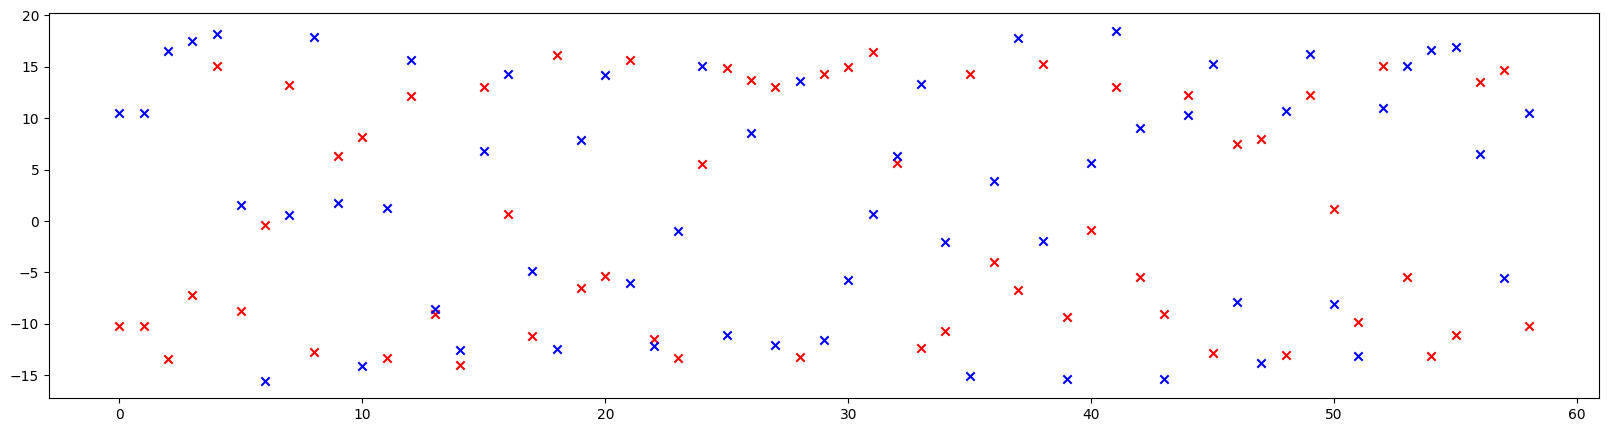

In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**12

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[model.monitor_index, ..., 0]
y = trajectory[model.monitor_index, ..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[index], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(BX - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(BY - model.by)/model.by, color='blue', marker='x')
plt.show()

NUX= 0.536666935
nux= 0.536666935, sigma_nux=1.66373862e-16, error_nux=1.11022302e-16

NUY= 0.581841806
nuy= 0.581841806, sigma_nuy=3.27679592e-16, error_nuy=1.22124533e-15



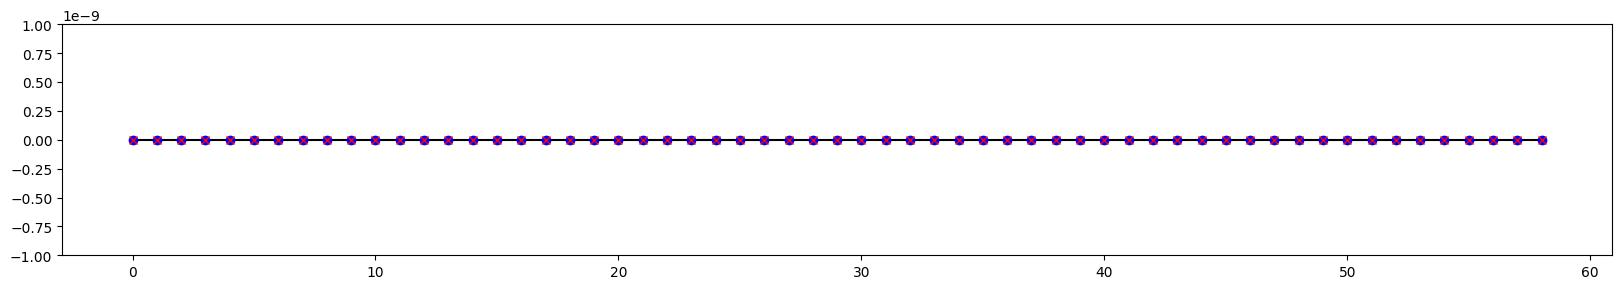

In [6]:
# Compute reference parameters from clean data at all locations

# Set window

win = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

# Estimate frequency, amplitude and phase for x plane

tbt = Data.from_data(win, trajectory[..., 0])

f = Frequency(tbt)
tbt.window_remove_mean()
tbt.window_apply()
f('parabola')
tbt.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')
print()

d = Decomposition(tbt)
ax_ref, sigma_ax, *_ = d.harmonic_amplitude(nux, length=2048, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=512, step=16, method='none')
fx_ref, sigma_fx, *_ = d.harmonic_phase(nux, length=2048, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=512, step=16, method='none')

# Estimate frequency, amplitude and phase for y plane

tbt = Data.from_data(win, trajectory[..., 2])

f = Frequency(tbt)
tbt.window_remove_mean()
tbt.window_apply()
f('parabola')
tbt.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')
print()

d = Decomposition(tbt)
ay_ref, sigma_ay, *_ = d.harmonic_amplitude(nuy, length=2048, order=2.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=512, step=16, method='none')
fy_ref, sigma_fy, *_ = d.harmonic_phase(nuy, length=2048, order=2.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=512, step=16, method='none')

# Phase advance between locations

plt.figure(figsize=(20, 3))

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX)
advance, _ = Decomposition.phase_adjacent(nux, fx_ref)

plt.errorbar(range(model.size), mod(ADVANCE - advance, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), fmt=' ', marker='o', color='blue')

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY)
advance, _ = Decomposition.phase_adjacent(nuy, fy_ref)

plt.errorbar(range(model.size), mod(ADVANCE - advance, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), fmt=' ', marker='x', color='red')

plt.ylim(-1.0E-9, +1.0E-9)
plt.hlines(0, 0, model.size - 1, colors='black')

plt.show()

In [7]:
# Generate TbT data with noise

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(1024, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x[:, :1024])
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y[:, :1024])
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(29, Window(1024, 'cosine_window', 1.0))
Data(29, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Note, with coupling using window for phase estimation might impove the accuracy
# Here, window of order 0.5 is used for phase estimation

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')
print()

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=256, order=0.5, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

print((ax - ax_ref[model.monitor_index]).abs().sum().item())
print((fx - fx_ref[model.monitor_index]).abs().sum().item())

NUX= 0.536666935
nux= 0.536666948, sigma_nux=1.01652942e-07, error_nux=1.35107668e-08

1.2971684059477542e-05
0.0035040828264893634


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')
print()

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=256, order=0.5, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

print((ay - ay_ref[model.monitor_index]).abs().sum().item())
print((fy - fy_ref[model.monitor_index]).abs().sum().item())

NUY= 0.581841806
nuy= 0.581841784, sigma_nuy=1.25602457e-07, error_nuy=2.23421431e-08

8.891107384164732e-06
0.005078363651742468


0.005167602785484671
0.0060033922307847765

0.02112516749135379
0.2506879229301255

0.021116438274089155
0.2506839802158924

0.017353839403226046
0.015437872123067908



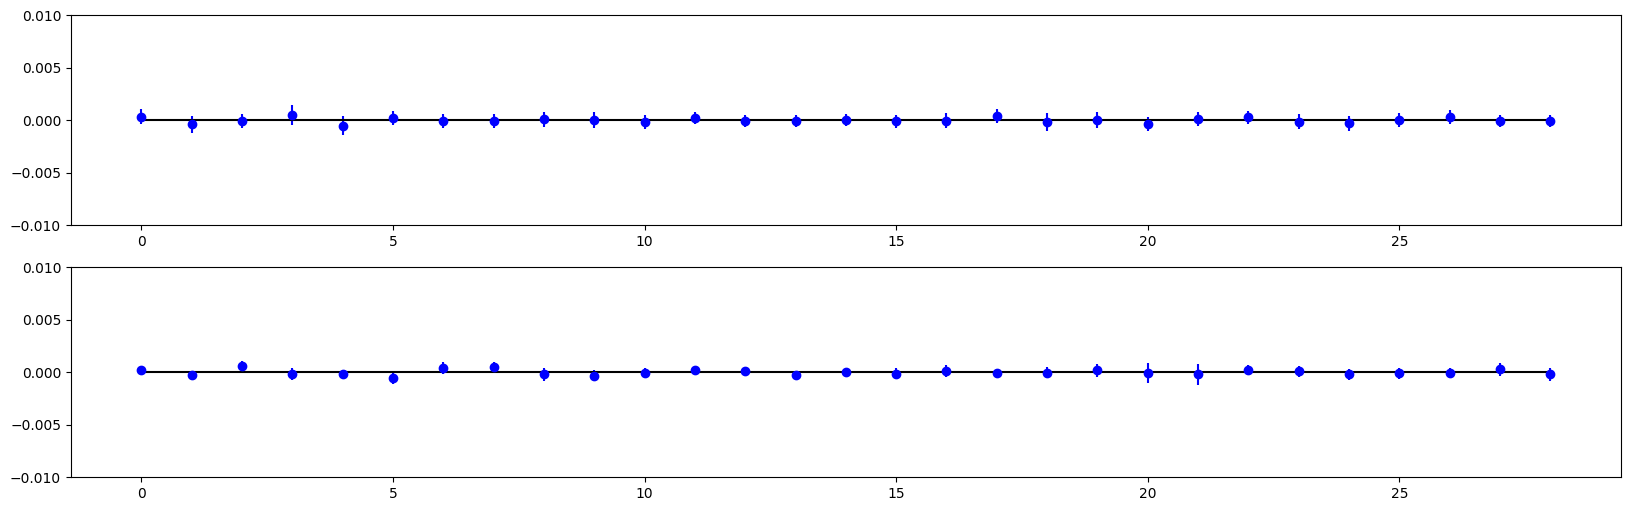

In [10]:
# Set table

table = Table(
    model.monitor_name,
    nux, nuy, ax, ay, fx, fy,
    sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    accumulate=True,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(NUX, mux)
muy, _ = Decomposition.phase_adjacent(NUY, muy)

print((mux - table.phase_x).abs().sum().item())
print((muy - table.phase_y).abs().sum().item())
print()

# Phase advance from SVD (scales with signal length & number of signals)

mux_svd = Decomposition.svd_advance(nux, X.data)
muy_svd = Decomposition.svd_advance(nuy, Y.data)

print((mux - mux_svd).abs().sum().item())
print((muy - muy_svd).abs().sum().item())
print()

# Phase advance from ICA (scales with signal length & number of signals)

mux_ica = Decomposition.ica_advance(nux, X.data, mux, whiten='unit-variance')
muy_ica = Decomposition.ica_advance(nuy, Y.data, muy, whiten='unit-variance')

print((mux - mux_ica).abs().sum().item())
print((muy - muy_ica).abs().sum().item())
print()

# Phase advance from DHT (scales with signal length)
# Note, best performance on signals with only one component

mux_dht, _ = Decomposition.dht_phase(nux, X.data)
muy_dht, _ = Decomposition.dht_phase(nuy, Y.data)

mux_dht, _ = Decomposition.phase_adjacent(nux, mux_dht)
muy_dht, _ = Decomposition.phase_adjacent(nuy, muy_dht)

print((mux - mux_dht).abs().sum().item())
print((muy - muy_dht).abs().sum().item())
print()

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, model.monitor_count - 1, colors='black')
ax1.set_ylim(-1.0E-2, +1.0E-2)

ax2 = plt.subplot(212)
ax2.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, model.monitor_count - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

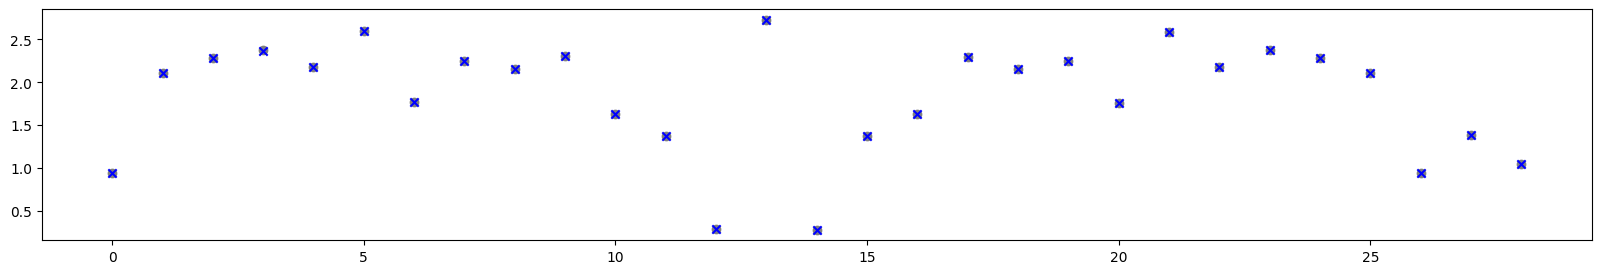

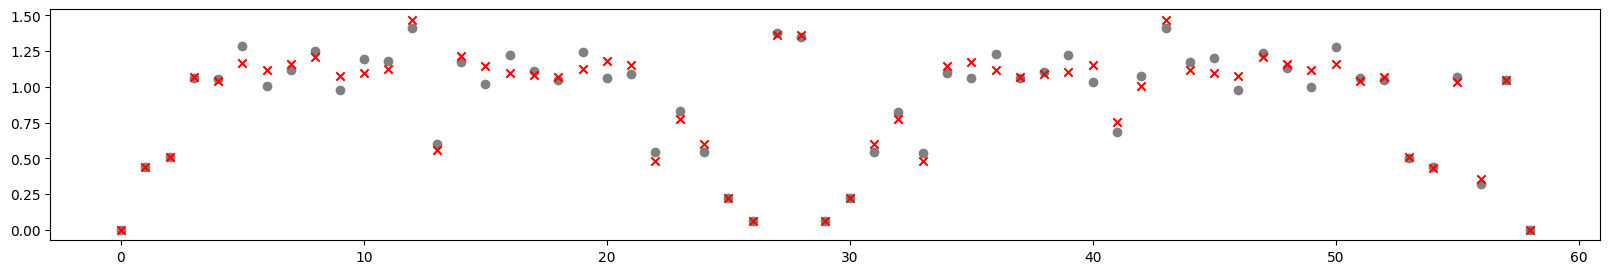

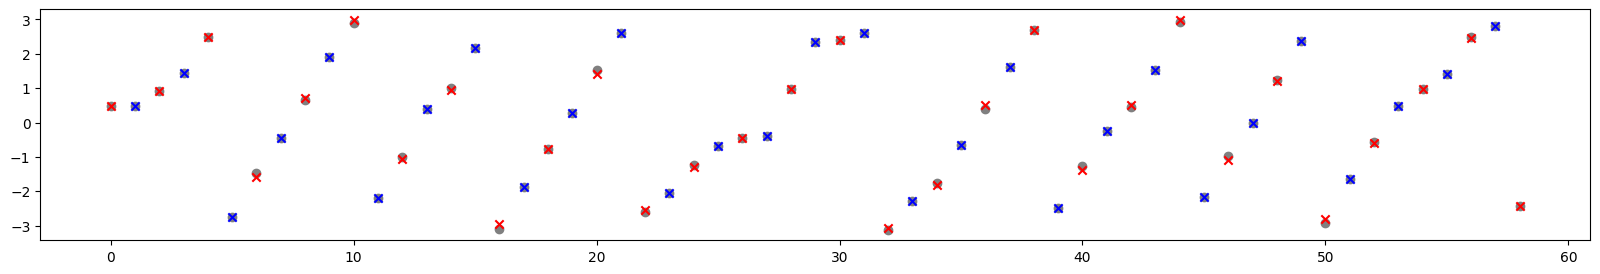

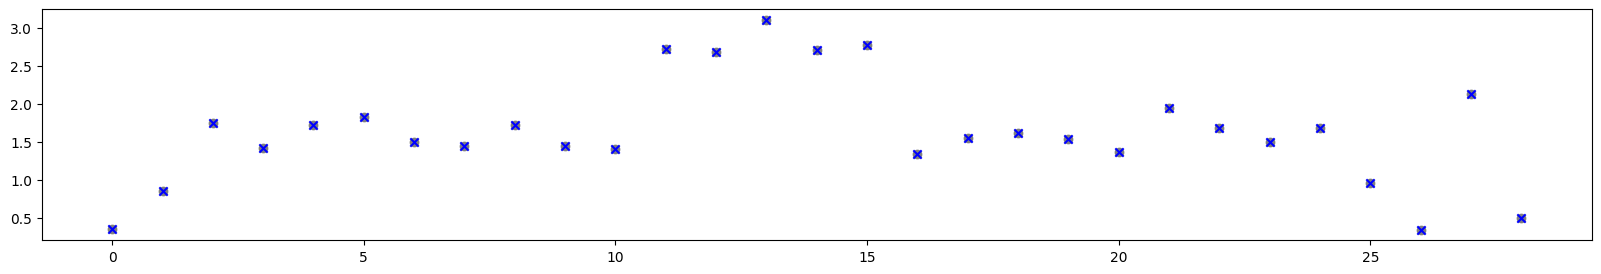

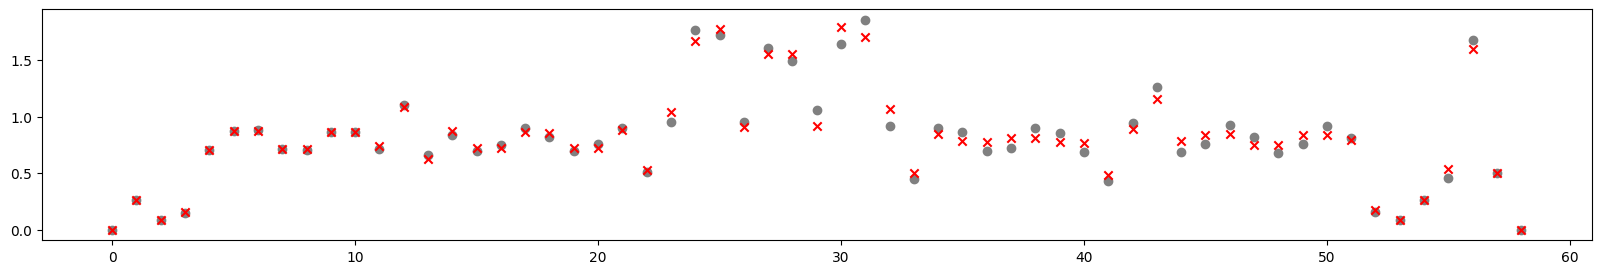

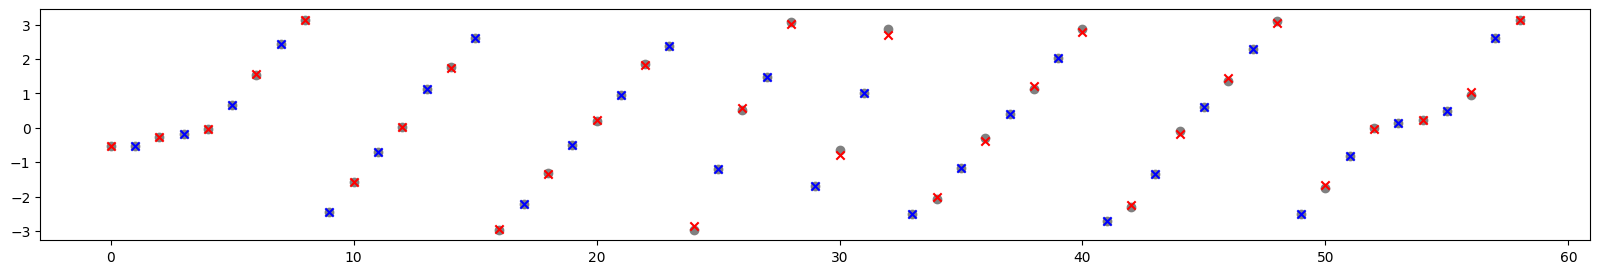

In [11]:
# Compute virtual phase (interpolation)

twiss = Twiss(model, table)
twiss.phase_virtual(method='interpolate')

# Compare with reference

# Phase advance between monitor locations

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX[model.monitor_index])
advance, _ = Decomposition.phase_adjacent(nux, twiss.fx[model.monitor_index])

for index in range(1, model.monitor_count):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.monitor_count), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.monitor_count), mod(advance, 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.show()

# Phase advance between adjacent locations

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX)
advance, _ = Decomposition.phase_adjacent(nux, twiss.fx)

for index in range(1, model.size):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.size), mod(advance, 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

# Phase

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(fx_ref, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(model.monitor_index, mod(twiss.fx[model.monitor_index], 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.scatter(model.virtual_index, mod(twiss.fx[model.virtual_index], 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

# Phase advance between monitor locations

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY[model.monitor_index])
advance, _ = Decomposition.phase_adjacent(nuy, twiss.fy[model.monitor_index])

for index in range(1, model.monitor_count):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.monitor_count), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.monitor_count), mod(advance, 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.show()

# Phase advance between adjacent locations

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY)
advance, _ = Decomposition.phase_adjacent(nuy, twiss.fy)

for index in range(1, model.size):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.size), mod(advance, 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

# Phase

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(fy_ref, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(model.monitor_index, mod(twiss.fy[model.monitor_index], 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.scatter(model.virtual_index, mod(twiss.fy[model.virtual_index], 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

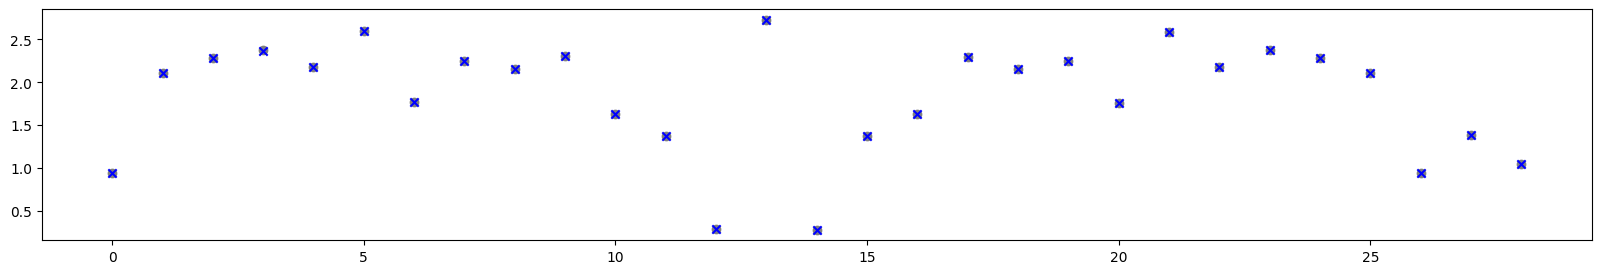

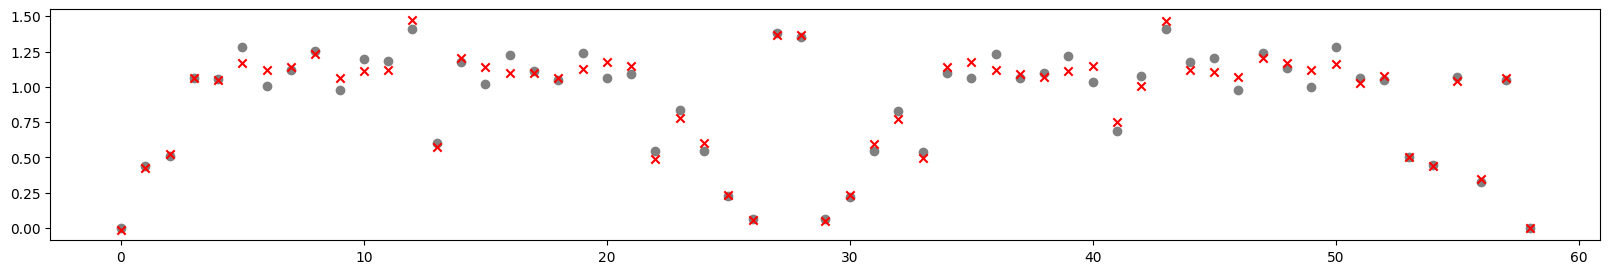

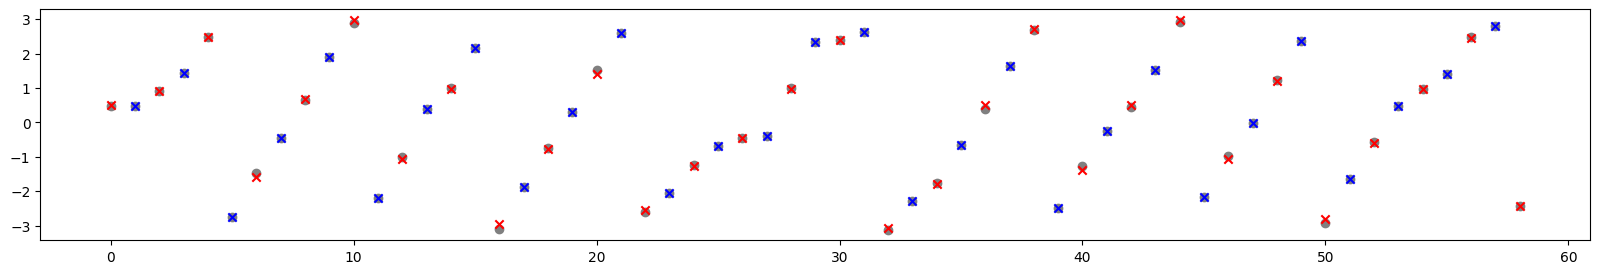

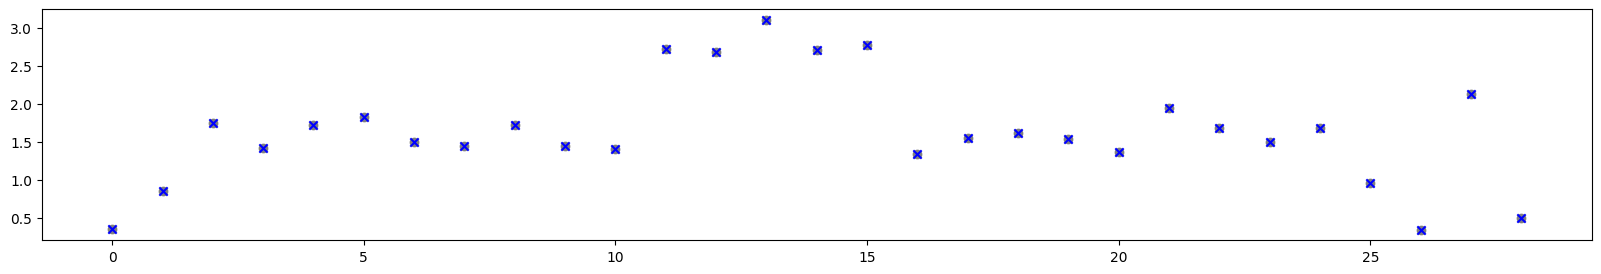

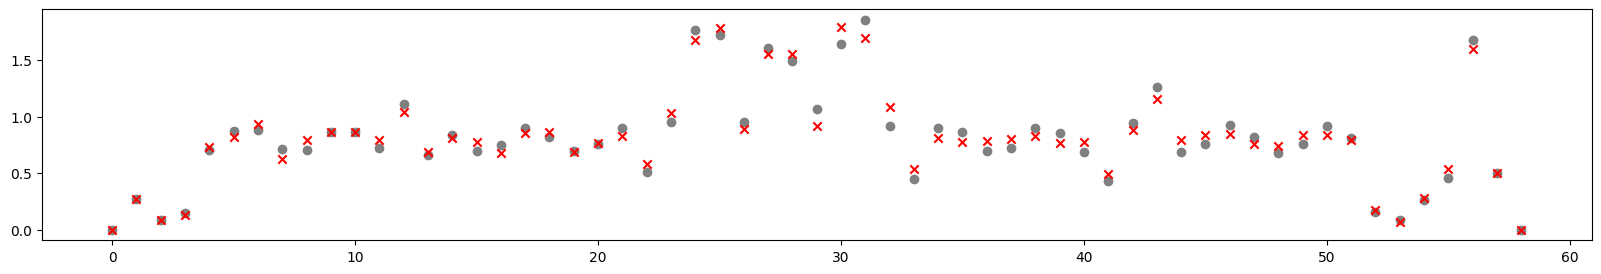

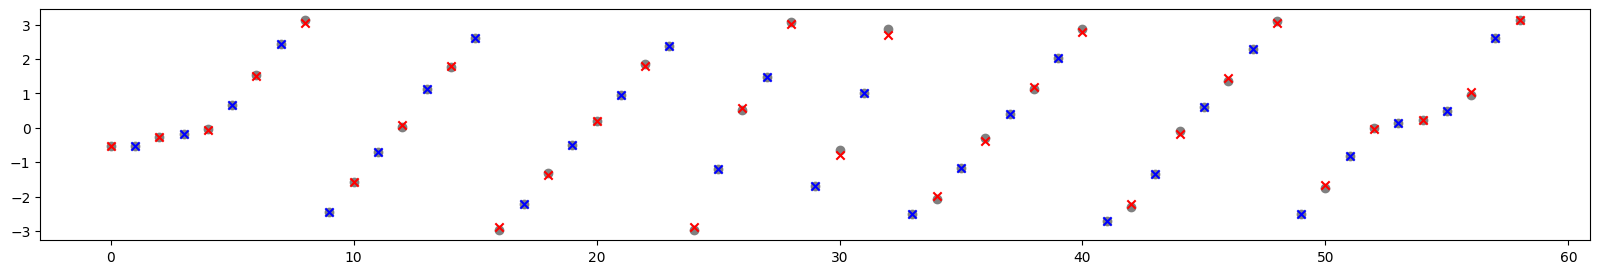

In [12]:
# Compute virtual phase (model)

twiss = Twiss(model, table)
twiss.phase_virtual(method='model', limit=1)

# Phase advance between monitor locations

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX[model.monitor_index])
advance, _ = Decomposition.phase_adjacent(nux, twiss.fx[model.monitor_index])

for index in range(1, model.monitor_count):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.monitor_count), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.monitor_count), mod(advance, 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.show()

# Phase advance between adjacent locations

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX)
advance, _ = Decomposition.phase_adjacent(nux, twiss.fx)

for index in range(1, model.size):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.size), mod(advance, 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

# Phase

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(fx_ref, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(model.monitor_index, mod(twiss.fx[model.monitor_index], 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.scatter(model.virtual_index, mod(twiss.fx[model.virtual_index], 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

# Phase advance between monitor locations

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY[model.monitor_index])
advance, _ = Decomposition.phase_adjacent(nuy, twiss.fy[model.monitor_index])

for index in range(1, model.monitor_count):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.monitor_count), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.monitor_count), mod(advance, 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.show()

# Phase advance between adjacent locations

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY)
advance, _ = Decomposition.phase_adjacent(nuy, twiss.fy)

for index in range(1, model.size):
    while ADVANCE[index] < ADVANCE[index - 1]: ADVANCE[index:] += 2.0*numpy.pi
    while advance[index] < advance[index - 1]: advance[index:] += 2.0*numpy.pi

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(ADVANCE, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(range(model.size), mod(advance, 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

# Phase

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), mod(fy_ref, 2.0*numpy.pi, -numpy.pi), color='gray', marker='o')
plt.scatter(model.monitor_index, mod(twiss.fy[model.monitor_index], 2.0*numpy.pi, -numpy.pi), color='blue', marker='x')
plt.scatter(model.virtual_index, mod(twiss.fy[model.virtual_index], 2.0*numpy.pi, -numpy.pi), color='red', marker='x')
plt.show()

In [13]:
# Note, virtual phases (and amplitudes) can be also computed from virtual trajectories
# See Momenta estimation & virtual trajectories example

# Estimate twiss from phase (virtual phase is used at virtual locations)

twiss = Twiss(model, table, limit=4)
twiss.phase_virtual(method='model',  limit=1)
twiss.get_twiss_from_phase()

# Filter and process

mask_x = twiss.filter_twiss(plane='x', 
                            phase={'use': True, 'threshold': 10.0}, 
                            model={'use': False, 'threshold': 0.50}, 
                            value={'use': False, 'threshold': 0.50}, 
                            sigma={'use': False, 'threshold': 0.50}, 
                            limit={'use': True, 'threshold': 5.0},
                            error={'use': True, 'threshold': 5.0})

twiss.process_twiss(plane='x', mask=mask_x, weight=True) ;

mask_y = twiss.filter_twiss(plane='y', 
                            phase={'use': True, 'threshold': 10.0}, 
                            model={'use': False, 'threshold': 0.50}, 
                            value={'use': False, 'threshold': 0.50}, 
                            sigma={'use': False, 'threshold': 0.50}, 
                            limit={'use': True, 'threshold': 5.0},
                            error={'use': True, 'threshold': 5.0})

twiss.process_twiss(plane='y', mask=mask_y, weight=True) ;

# Note, can use amplitude data to estimate twiss (with corrected actions from phase twiss)
# Once computed, set twiss.bx & twiss.by

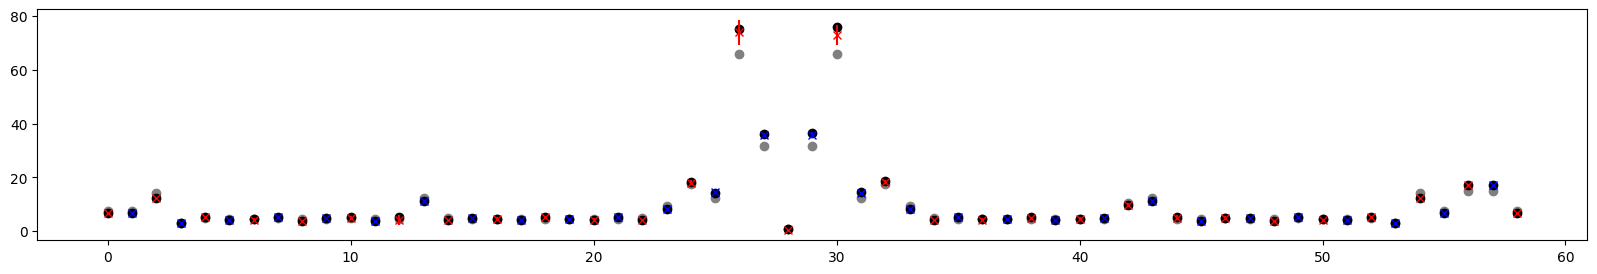

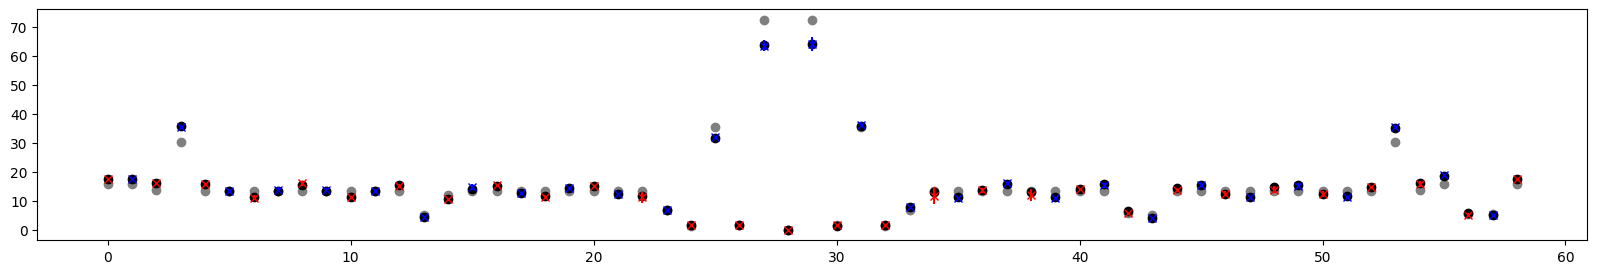

tensor(5.772691185186e-01, dtype=torch.float64)
tensor(8.077226112160e+00, dtype=torch.float64)

tensor(1.997078924735e+00, dtype=torch.float64)
tensor(5.363495936556e+00, dtype=torch.float64)



In [14]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.bx, color='gray', marker='o')
plt.scatter(range(model.size), BX, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, twiss.bx[model.virtual_index], yerr=twiss.sigma_bx[model.virtual_index], fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.by, color='gray', marker='o')
plt.scatter(range(model.size), BY, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.by[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, twiss.by[model.virtual_index], yerr=twiss.sigma_by[model.virtual_index], fmt=' ', color='red', marker='x')
plt.show()

print((BX[model.monitor_index] - twiss.bx[model.monitor_index]).sum().abs())
print((BX[model.virtual_index] - twiss.bx[model.virtual_index]).sum().abs())
print()

print((BY[model.monitor_index] - twiss.by[model.monitor_index]).sum().abs())
print((BY[model.virtual_index] - twiss.by[model.virtual_index]).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

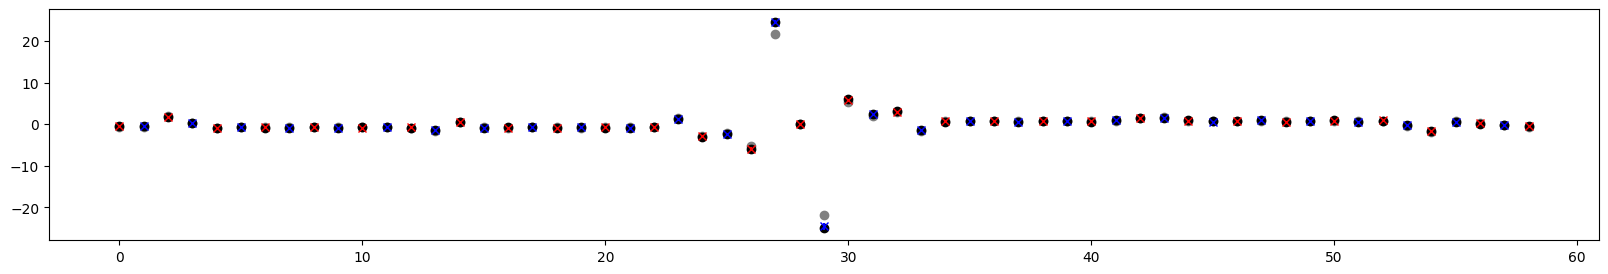

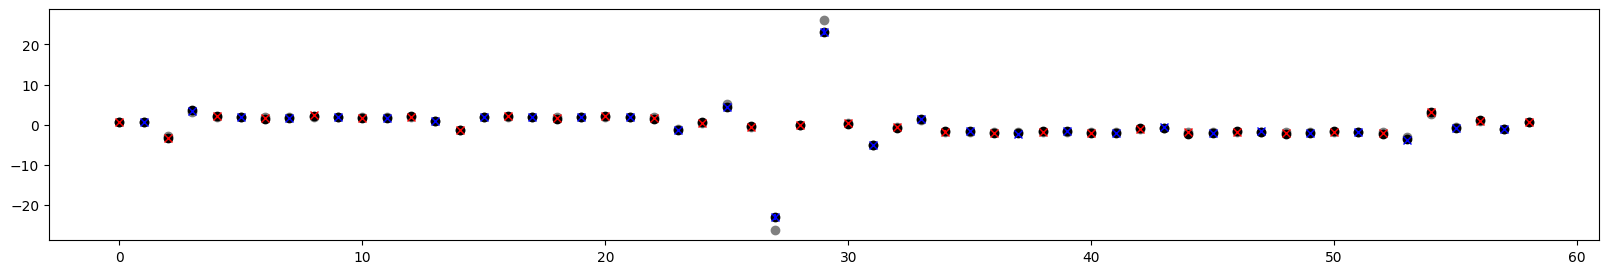

tensor(1.285575282985e-01, dtype=torch.float64)
tensor(1.821183488433e-01, dtype=torch.float64)

tensor(1.925447941297e-01, dtype=torch.float64)
tensor(7.794902518936e-01, dtype=torch.float64)



In [15]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ax, color='gray', marker='o')
plt.scatter(range(model.size), AX, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.ax[model.monitor_index], yerr=twiss.sigma_ax[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, twiss.ax[model.virtual_index], yerr=twiss.sigma_ax[model.virtual_index], fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ay, color='gray', marker='o')
plt.scatter(range(model.size), AY, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.ay[model.monitor_index], yerr=twiss.sigma_ay[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, twiss.ay[model.virtual_index], yerr=twiss.sigma_ay[model.virtual_index], fmt=' ', color='red', marker='x')
plt.show()

print((AX[model.monitor_index] - twiss.ax[model.monitor_index]).sum().abs())
print((AX[model.virtual_index] - twiss.ax[model.virtual_index]).sum().abs())
print()

print((AY[model.monitor_index] - twiss.ay[model.monitor_index]).sum().abs())
print((AY[model.virtual_index] - twiss.ay[model.virtual_index]).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [16]:
# Twiss at virtual locations from twiss transport (without virtual phase)

value_cs = []
error_cs = []

for virtual in model.virtual_index:
    value, error = twiss.get_twiss_virtual_uncoupled(virtual, limit=1, use_phase=False, bootstrap=True, count=128)
    value_cs.append(value)
    error_cs.append(error)

value_ax, value_bx, value_ay, value_by = torch.stack(value_cs).T
error_ax, error_bx, error_ay, error_by = torch.stack(error_cs).T

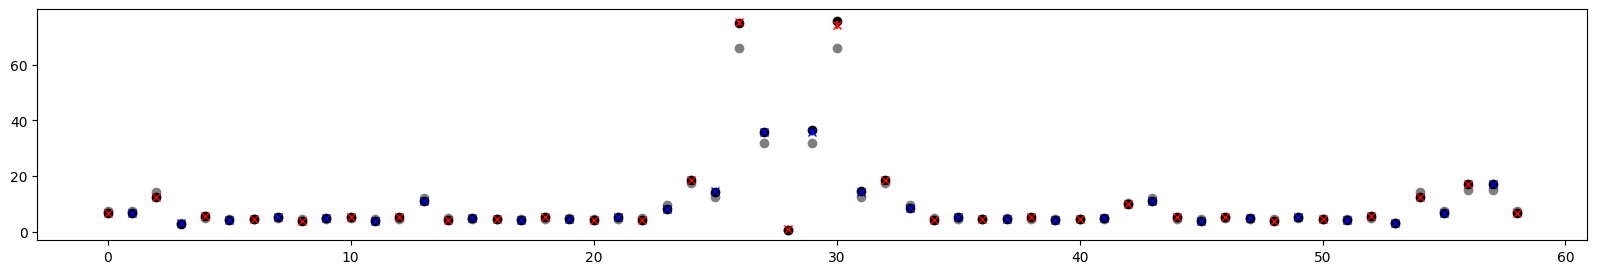

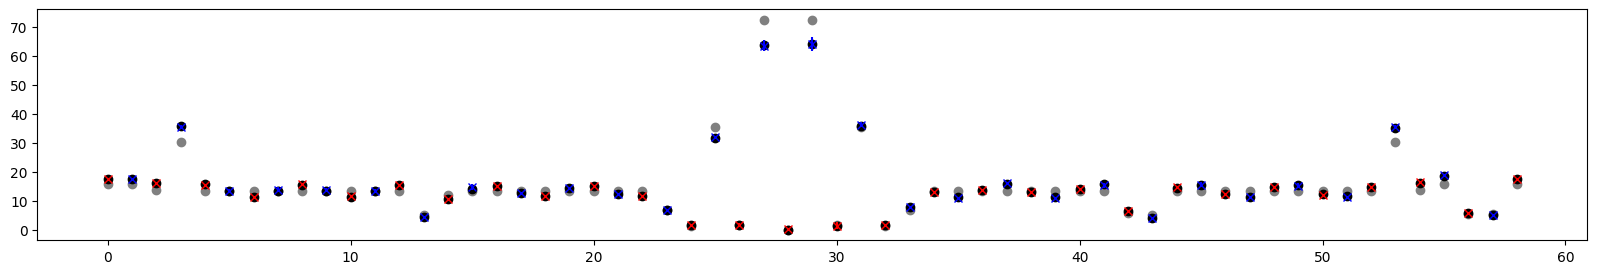

tensor(5.772691185186e-01, dtype=torch.float64)
tensor(4.987053243806e-01, dtype=torch.float64)

tensor(1.997078924735e+00, dtype=torch.float64)
tensor(2.610286739575e+00, dtype=torch.float64)



In [17]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.bx, color='gray', marker='o')
plt.scatter(range(model.size), BX, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_bx, yerr=error_bx, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.by, color='gray', marker='o')
plt.scatter(range(model.size), BY, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.by[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_by, yerr=error_by, fmt=' ', color='red', marker='x')
plt.show()

print((BX[model.monitor_index] - twiss.bx[model.monitor_index]).sum().abs())
print((BX[model.virtual_index] - value_bx).sum().abs())
print()

print((BY[model.monitor_index] - twiss.by[model.monitor_index]).sum().abs())
print((BY[model.virtual_index] - value_by).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

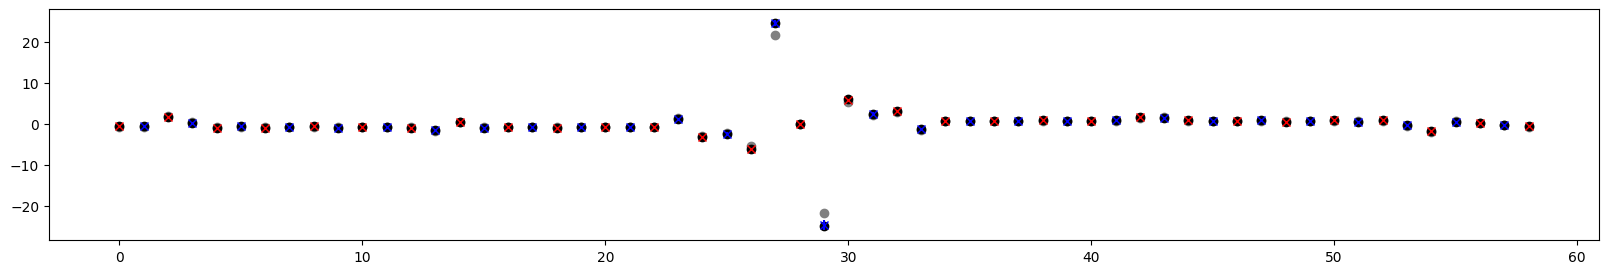

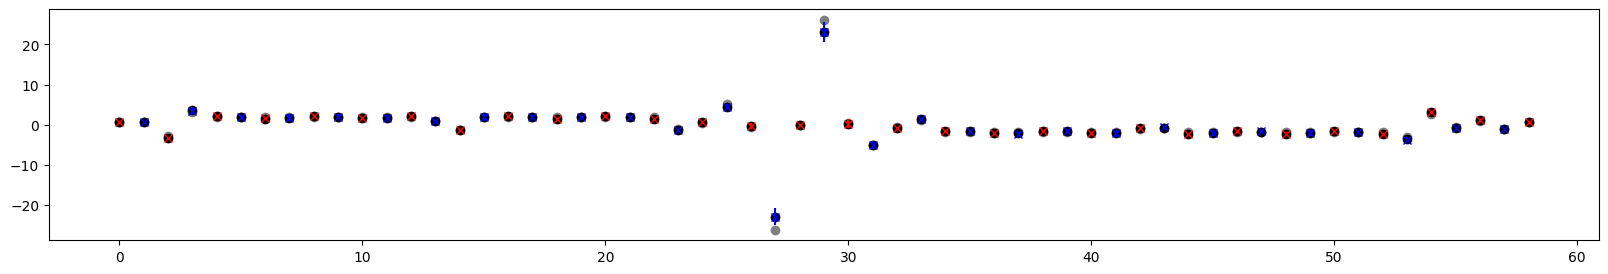

tensor(1.285575282985e-01, dtype=torch.float64)
tensor(2.712453501787e-01, dtype=torch.float64)

tensor(1.925447941297e-01, dtype=torch.float64)
tensor(1.023329088123e-01, dtype=torch.float64)



In [18]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ax, color='gray', marker='o')
plt.scatter(range(model.size), AX, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.ax[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ax, yerr=error_ax, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ay, color='gray', marker='o')
plt.scatter(range(model.size), AY, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.ay[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ay, yerr=error_by, fmt=' ', color='red', marker='x')
plt.show()

print((AX[model.monitor_index] - twiss.ax[model.monitor_index]).sum().abs())
print((AX[model.virtual_index] - value_ax).sum().abs())
print()

print((AY[model.monitor_index] - twiss.ay[model.monitor_index]).sum().abs())
print((AY[model.virtual_index] - value_ay).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [19]:
# Twiss at virtual locations from twiss transport (with virtual phase)

value_cs = []
error_cs = []

for virtual in model.virtual_index:
    value, error = twiss.get_twiss_virtual_uncoupled(virtual, limit=1, use_phase=True, bootstrap=True, count=128)
    value_cs.append(value)
    error_cs.append(error)

value_ax, value_bx, value_ay, value_by = torch.stack(value_cs).T
error_ax, error_bx, error_ay, error_by = torch.stack(error_cs).T

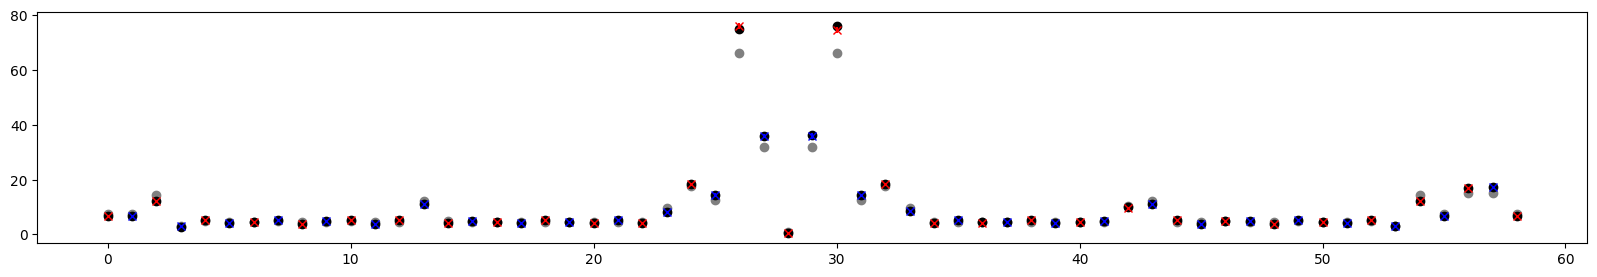

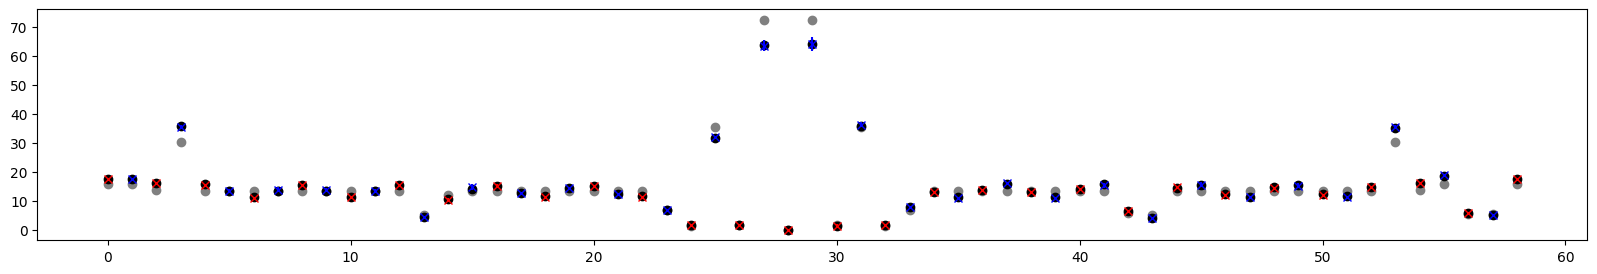

tensor(5.772691185186e-01, dtype=torch.float64)
tensor(1.228888240050e+00, dtype=torch.float64)

tensor(1.997078924735e+00, dtype=torch.float64)
tensor(5.730778129199e-01, dtype=torch.float64)



In [20]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.bx, color='gray', marker='o')
plt.scatter(range(model.size), BX, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_bx, yerr=error_bx, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.by, color='gray', marker='o')
plt.scatter(range(model.size), BY, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.by[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_by, yerr=error_by, fmt=' ', color='red', marker='x')
plt.show()

print((BX[model.monitor_index] - twiss.bx[model.monitor_index]).sum().abs())
print((BX[model.virtual_index] - value_bx).sum().abs())
print()

print((BY[model.monitor_index] - twiss.by[model.monitor_index]).sum().abs())
print((BY[model.virtual_index] - value_by).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

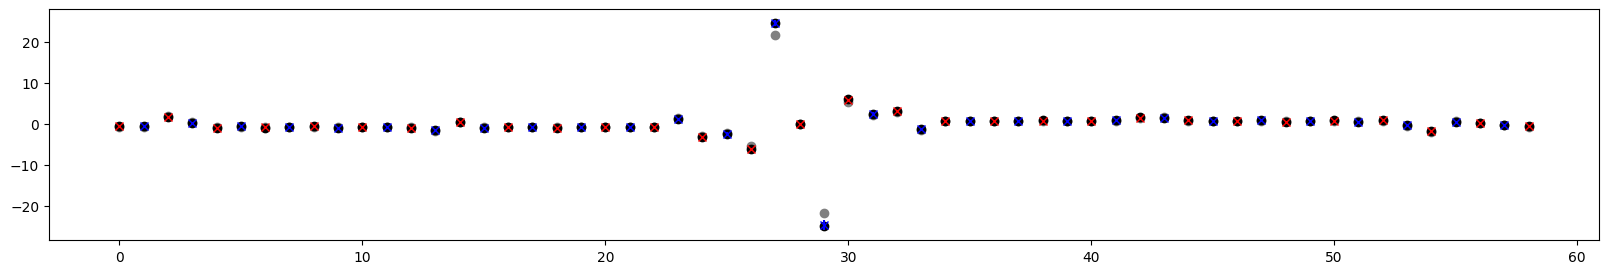

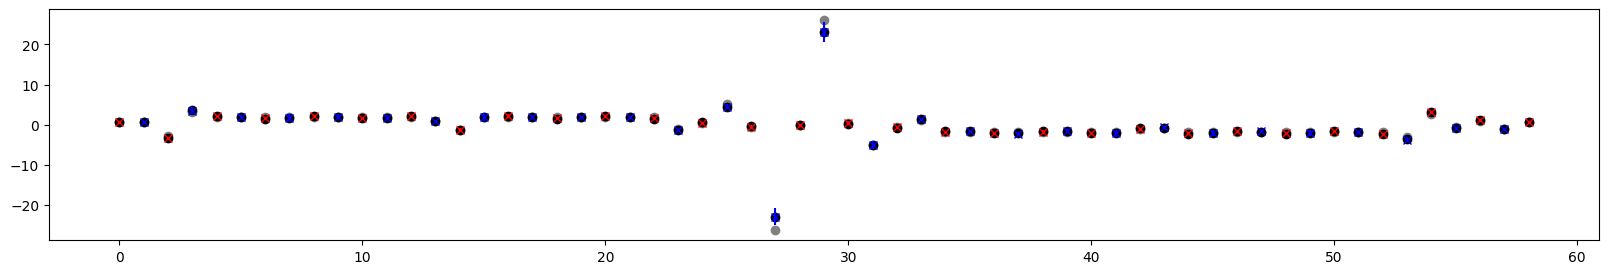

tensor(1.285575282985e-01, dtype=torch.float64)
tensor(1.905286730011e-01, dtype=torch.float64)

tensor(1.925447941297e-01, dtype=torch.float64)
tensor(2.364045184825e-01, dtype=torch.float64)



In [21]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ax, color='gray', marker='o')
plt.scatter(range(model.size), AX, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.ax[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ax, yerr=error_ax, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ay, color='gray', marker='o')
plt.scatter(range(model.size), AY, color='black', marker='o')
plt.errorbar(model.monitor_index, twiss.ay[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ay, yerr=error_by, fmt=' ', color='red', marker='x')
plt.show()

print((AX[model.monitor_index] - twiss.ax[model.monitor_index]).sum().abs())
print((AX[model.virtual_index] - value_ax).sum().abs())
print()

print((AY[model.monitor_index] - twiss.ay[model.monitor_index]).sum().abs())
print((AY[model.virtual_index] - value_ay).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [22]:
%%time

# Estimate twiss from invariant fit

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 product=True,
                                 jacobian=False,
                                 count=128,
                                 fraction=0.75,
                                 ix=None,
                                 iy=None,
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)

torch.Size([29, 2, 10, 128])
CPU times: user 27.4 s, sys: 892 ms, total: 28.2 s
Wall time: 31.4 s


In [23]:
# Process fitted invariants

ix, iy = data[:, 0, 0], data[:, 0, 1]
sigma_ix, sigma_iy = data[:, 1, 0], data[:, 1, 1]
invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

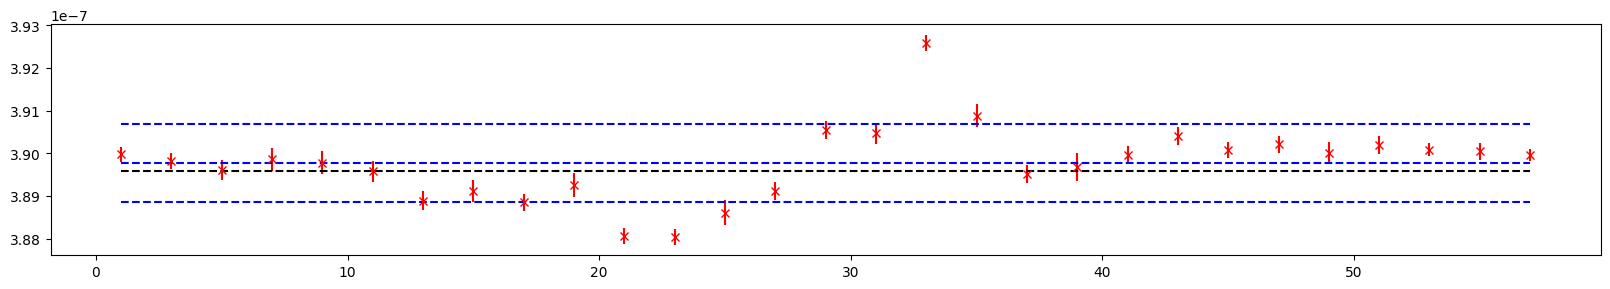

tensor(3.895864089541e-07, dtype=torch.float64)
tensor(3.897838314608e-07, dtype=torch.float64)
tensor(9.150709871768e-10, dtype=torch.float64)



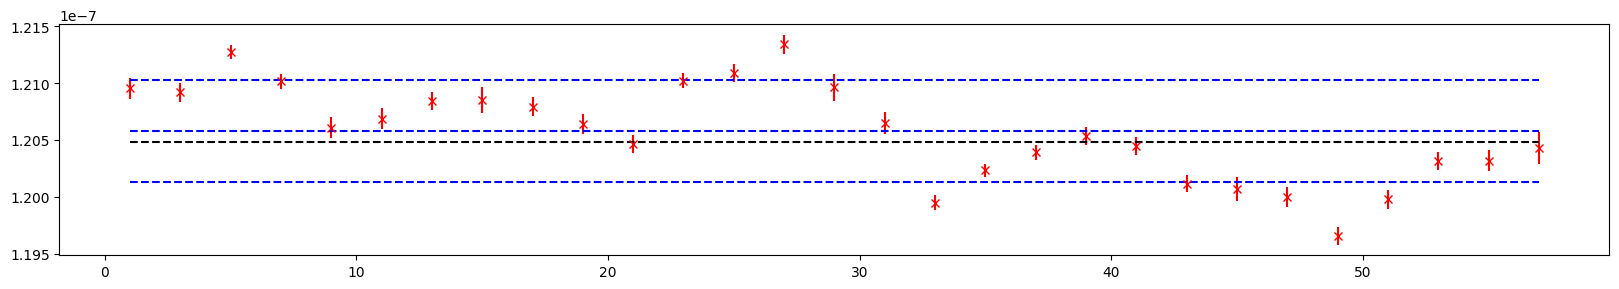

tensor(1.204828903224e-07, dtype=torch.float64)
tensor(1.205759415100e-07, dtype=torch.float64)
tensor(4.492127889660e-10, dtype=torch.float64)



In [24]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(model.monitor_index, invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(model.monitor_index, invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

In [25]:
# Process twiss

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value, error = data.permute(1, 2, 0, -1)

*_, value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41 = value
*_, error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41 = error

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

In [26]:
%%time

# Twiss at virtual locations (from virtual orbits)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 phony=True,
                                 product=True,
                                 jacobian=False,
                                 count=128,
                                 fraction=0.75,
                                 ix=invariant['ix_value'],
                                 iy=invariant['iy_value'],
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)
print(model.virtual_count)

torch.Size([30, 2, 8, 128])
30
CPU times: user 26 s, sys: 667 ms, total: 26.7 s
Wall time: 28.4 s


In [27]:
# Process twiss

value, error = data.permute(1, 2, 0, -1)

*_, value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41 = value
*_, error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41 = error

value_v11, error_v11 = twiss.process(value_v11, error_v11)
value_v33, error_v33 = twiss.process(value_v33, error_v33)
value_v21, error_v21 = twiss.process(value_v21, error_v21)
value_v43, error_v43 = twiss.process(value_v43, error_v43)
value_v13, error_v13 = twiss.process(value_v13, error_v13)
value_v31, error_v31 = twiss.process(value_v31, error_v31)
value_v14, error_v14 = twiss.process(value_v14, error_v14)
value_v41, error_v41 = twiss.process(value_v41, error_v41)

In [28]:
# Compute twiss at all locations from normalization

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_local, error_local in zip(value, error):
    table = value_local.reshape(-1, 1) + error_local.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax_m, value_bx_m, value_ay_m, value_by_m = cs_value.T
error_ax_m, error_bx_m, error_ay_m, error_by_m = cs_error.T

value = torch.stack([value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41]).T
error = torch.stack([error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41]).T

cs_value, cs_error = [], []

for value_local, error_local in zip(value, error):
    table = value_local.reshape(-1, 1) + error_local.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax_v, value_bx_v, value_ay_v, value_by_v = cs_value.T
error_ax_v, error_bx_v, error_ay_v, error_by_v = cs_error.T

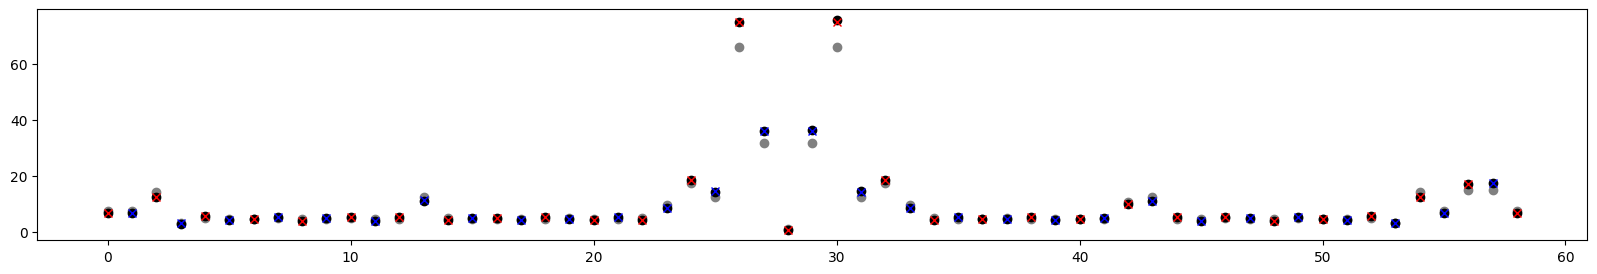

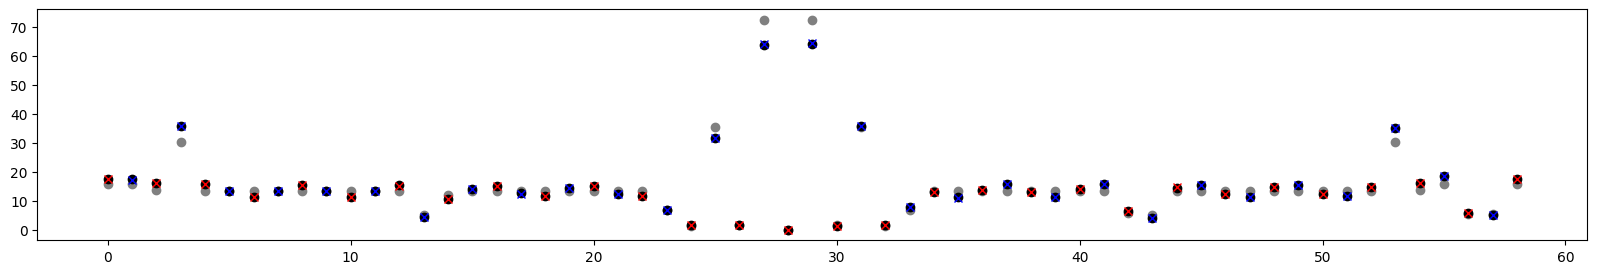

tensor(6.776524106307e-01, dtype=torch.float64)
tensor(6.568952269466e-01, dtype=torch.float64)

tensor(9.294318546498e-01, dtype=torch.float64)
tensor(1.020624713387e-01, dtype=torch.float64)



In [29]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.bx, color='gray', marker='o')
plt.scatter(range(model.size), BX, color='black', marker='o')
plt.errorbar(model.monitor_index, value_bx_m, yerr=error_bx_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_bx_v, yerr=error_bx_v, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.by, color='gray', marker='o')
plt.scatter(range(model.size), BY, color='black', marker='o')
plt.errorbar(model.monitor_index, value_by_m, yerr=error_by_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_by_v, yerr=error_by_v, fmt=' ', color='red', marker='x')
plt.show()

print((BX[model.monitor_index] - value_bx_m).sum().abs())
print((BX[model.virtual_index] - value_bx_v).sum().abs())
print()

print((BY[model.monitor_index] - value_by_m).sum().abs())
print((BY[model.virtual_index] - value_by_v).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

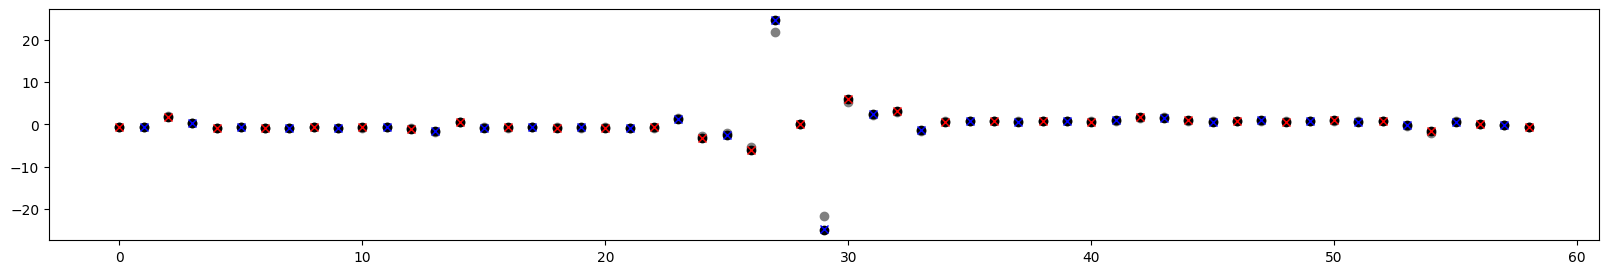

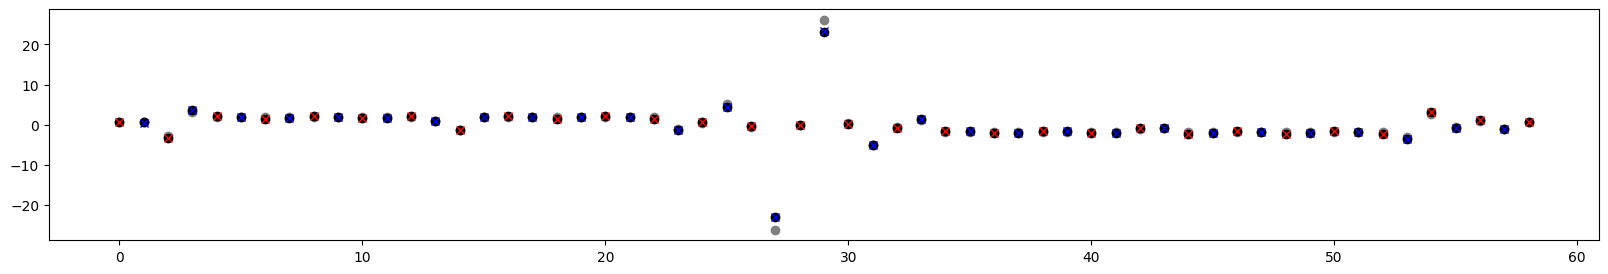

tensor(3.011280582035e-01, dtype=torch.float64)
tensor(7.417757571977e-02, dtype=torch.float64)

tensor(1.455606992380e-02, dtype=torch.float64)
tensor(1.288995316492e-01, dtype=torch.float64)



In [30]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ax, color='gray', marker='o')
plt.scatter(range(model.size), AX, color='black', marker='o')
plt.errorbar(model.monitor_index, value_ax_m, yerr=error_ax_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ax_v, yerr=error_ax_v, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ay, color='gray', marker='o')
plt.scatter(range(model.size), AY, color='black', marker='o')
plt.errorbar(model.monitor_index, value_ay_m, yerr=error_ay_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ay_v, yerr=error_ay_v, fmt=' ', color='red', marker='x')
plt.show()

print((AX[model.monitor_index] - value_ax_m).sum().abs())
print((AX[model.virtual_index] - value_ax_v).sum().abs())
print()

print((AY[model.monitor_index] - value_ay_m).sum().abs())
print((AY[model.virtual_index] - value_ay_v).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

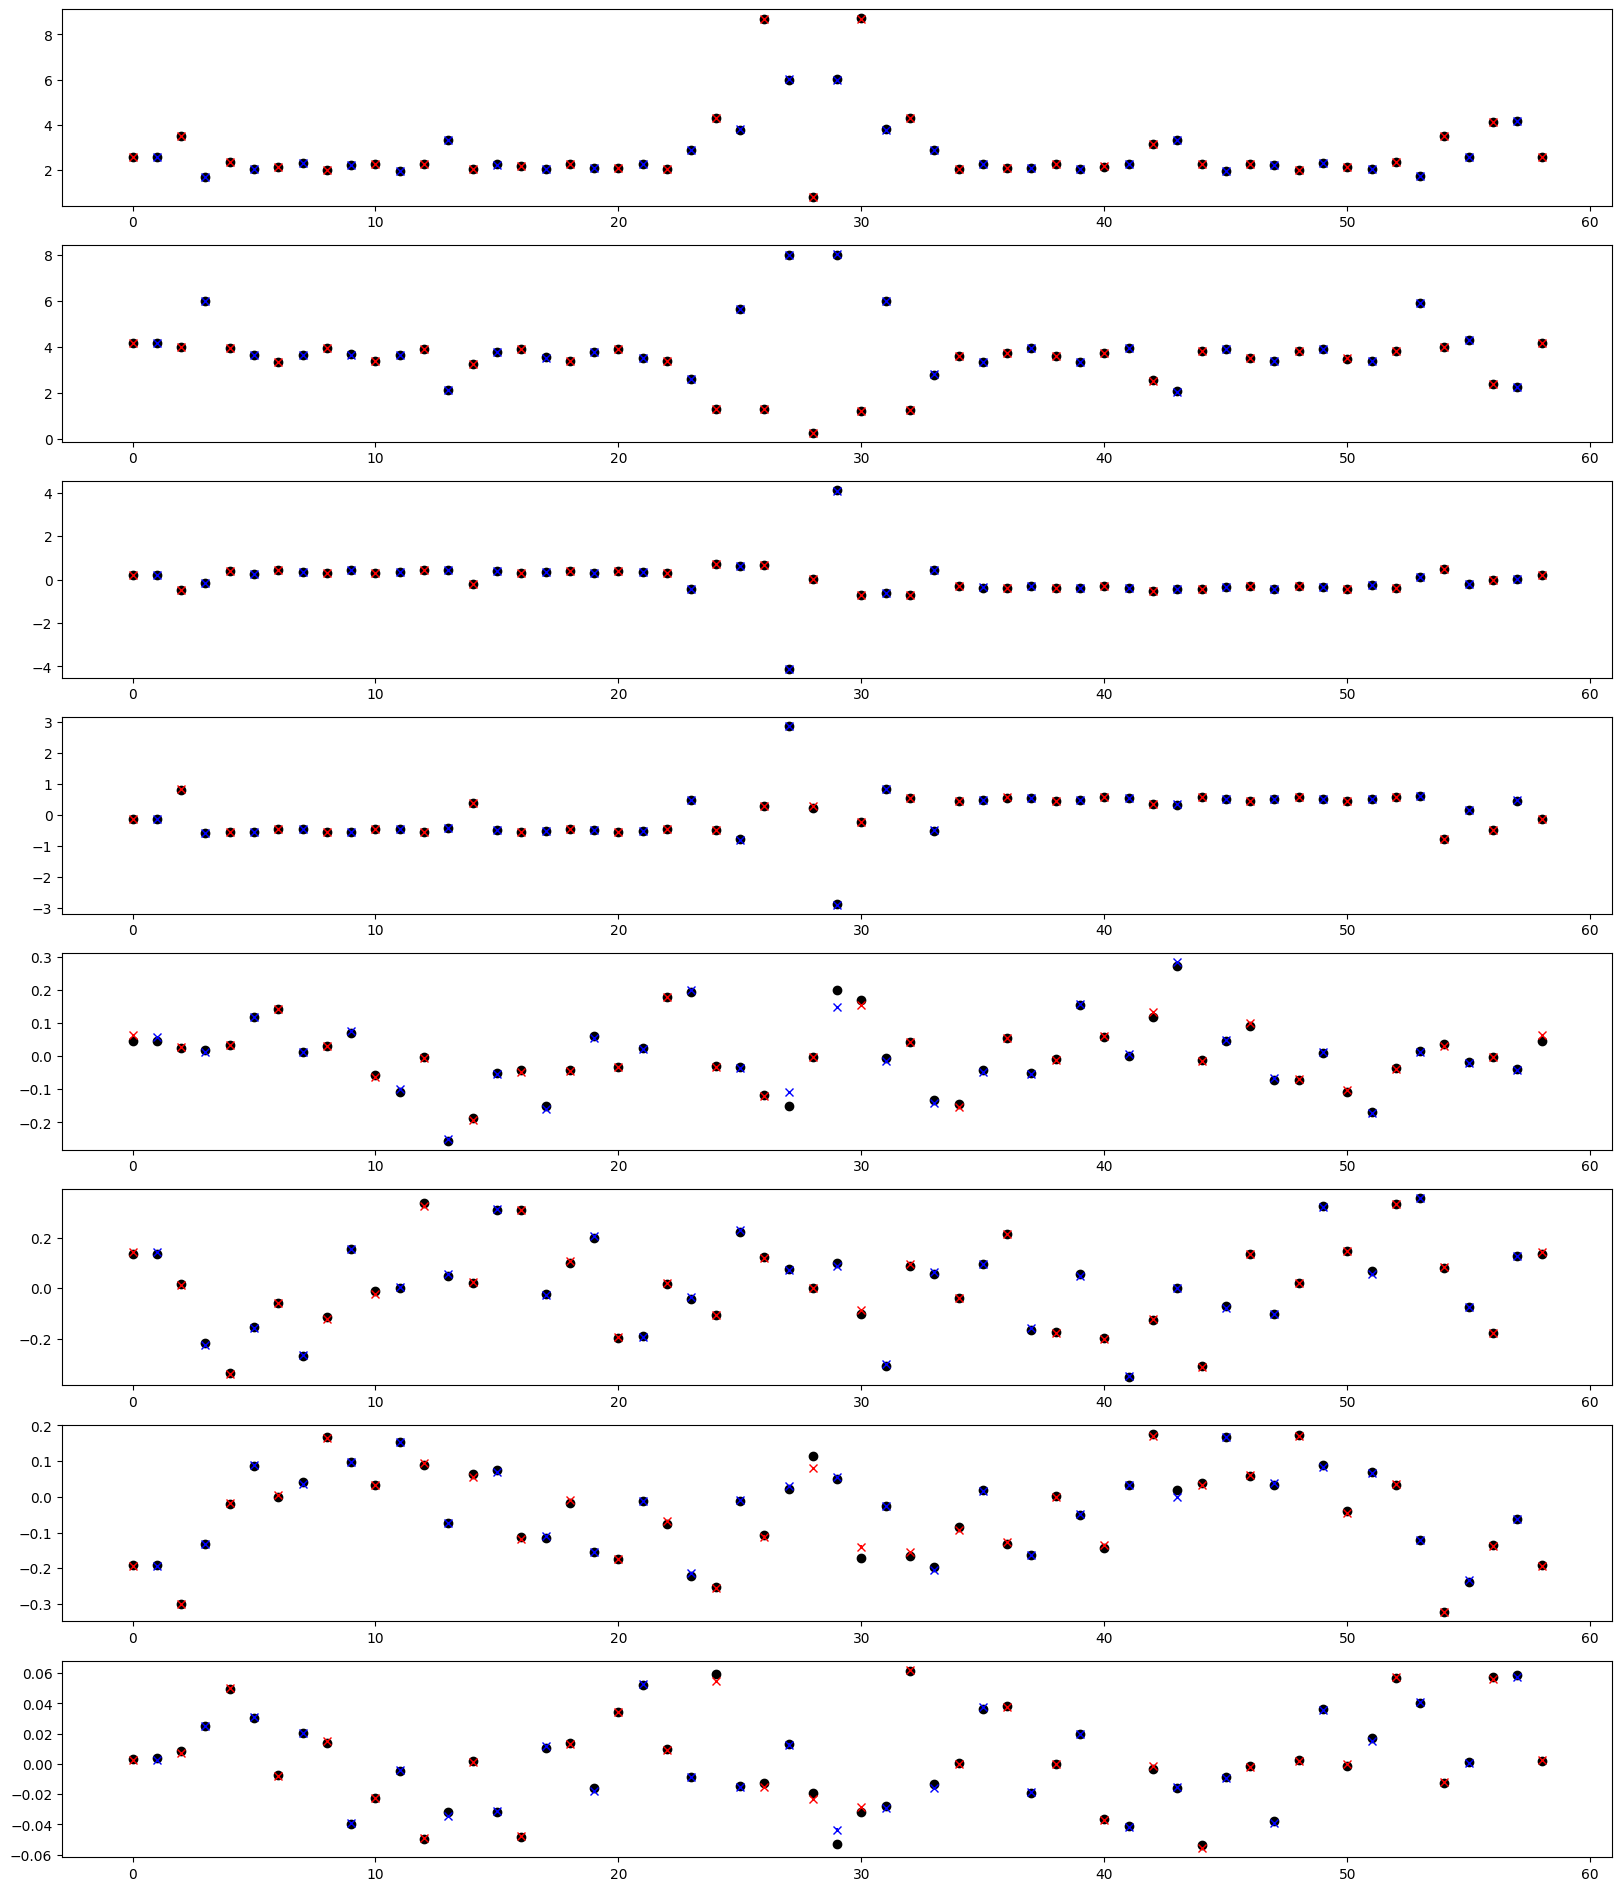

In [31]:
# Compare normalization matrix elements

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.size), N11, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n11, yerr=error_n11, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v11, yerr=error_v11, fmt=' ', color='red', marker='x')

ax = plt.subplot(812)
ax.scatter(range(model.size), N33, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n33, yerr=error_n33, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v33, yerr=error_v33, fmt=' ', color='red', marker='x')

ax = plt.subplot(813)
ax.scatter(range(model.size), N21, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n21, yerr=error_n21, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v21, yerr=error_v21, fmt=' ', color='red', marker='x')

ax = plt.subplot(814)
ax.scatter(range(model.size), N43, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n43, yerr=error_n43, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v43, yerr=error_v43, fmt=' ', color='red', marker='x')

ax = plt.subplot(815)
ax.scatter(range(model.size), N13, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n13, yerr=error_n13, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v13, yerr=error_v13, fmt=' ', color='red', marker='x')

ax = plt.subplot(816)
ax.scatter(range(model.size), N31, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n31, yerr=error_n31, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v31, yerr=error_v31, fmt=' ', color='red', marker='x')

ax = plt.subplot(817)
ax.scatter(range(model.size), N14, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n14, yerr=error_n14, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v14, yerr=error_v14, fmt=' ', color='red', marker='x')

ax = plt.subplot(818)
ax.scatter(range(model.size), N41, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n41, yerr=error_n41, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v41, yerr=error_v41, fmt=' ', color='red', marker='x')

plt.show()

# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [32]:
# Compare normalization matrix elements

print((N11[model.monitor_index] - value_n11).sum().abs())
print((N11[model.virtual_index] - value_v11).sum().abs())
print()

print((N33[model.monitor_index] - value_n33).sum().abs())
print((N33[model.virtual_index] - value_v33).sum().abs())
print()

print((N21[model.monitor_index] - value_n21).sum().abs())
print((N21[model.virtual_index] - value_v21).sum().abs())
print()

print((N43[model.monitor_index] - value_n43).sum().abs())
print((N43[model.virtual_index] - value_v43).sum().abs())
print()

print((N13[model.monitor_index] - value_n13).sum().abs())
print((N13[model.virtual_index] - value_v13).sum().abs())
print()

print((N31[model.monitor_index] - value_n31).sum().abs())
print((N31[model.virtual_index] - value_v31).sum().abs())
print()

print((N14[model.monitor_index] - value_n14).sum().abs())
print((N14[model.virtual_index] - value_v14).sum().abs())
print()

print((N41[model.monitor_index] - value_n41).sum().abs())
print((N41[model.virtual_index] - value_v41).sum().abs())
print()

tensor(7.245830231664e-02, dtype=torch.float64)
tensor(3.319472562170e-02, dtype=torch.float64)

tensor(6.143228279320e-02, dtype=torch.float64)
tensor(1.943381760806e-03, dtype=torch.float64)

tensor(2.524821957252e-02, dtype=torch.float64)
tensor(1.238719245889e-03, dtype=torch.float64)

tensor(1.418965215604e-02, dtype=torch.float64)
tensor(8.802371198988e-02, dtype=torch.float64)

tensor(1.015397300412e-02, dtype=torch.float64)
tensor(1.328074519416e-03, dtype=torch.float64)

tensor(1.394946572295e-02, dtype=torch.float64)
tensor(1.460341552275e-02, dtype=torch.float64)

tensor(3.231666328947e-03, dtype=torch.float64)
tensor(1.195004552641e-02, dtype=torch.float64)

tensor(3.120606942382e-03, dtype=torch.float64)
tensor(9.632742703862e-03, dtype=torch.float64)



In [33]:
# Set normal at monitor locations

model.model = 'coupled'

from harmonica.parameterization import parametric_normal
for index, (n11, n33, n21, n43, n13, n31, n14, n41) in enumerate(zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)):
    index = model.monitor_index[index]
    normal = parametric_normal(n11, n33, n21, n43, n13, n31, n14, n41, dtype=dtype)
    twiss.normal[index] = normal

# Set normal at virtual locations

model.model = 'coupled'

from harmonica.parameterization import parametric_normal
for index, (n11, n33, n21, n43, n13, n31, n14, n41) in enumerate(zip(value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41)):
    index = model.virtual_index[index]
    normal = parametric_normal(n11, n33, n21, n43, n13, n31, n14, n41, dtype=dtype)
    twiss.normal[index] = normal

In [34]:
# Twiss at virtual locations from transport (without virtual phase)

value_normal = []
error_normal = []

for virtual in model.virtual_index:
    value, error = twiss.get_twiss_virtual_coupled(virtual, limit=1, use_phase=False, bootstrap=True, count=128)
    value_normal.append(value)
    error_normal.append(error)

value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41 = torch.stack(value_normal).T
error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41 = torch.stack(error_normal).T

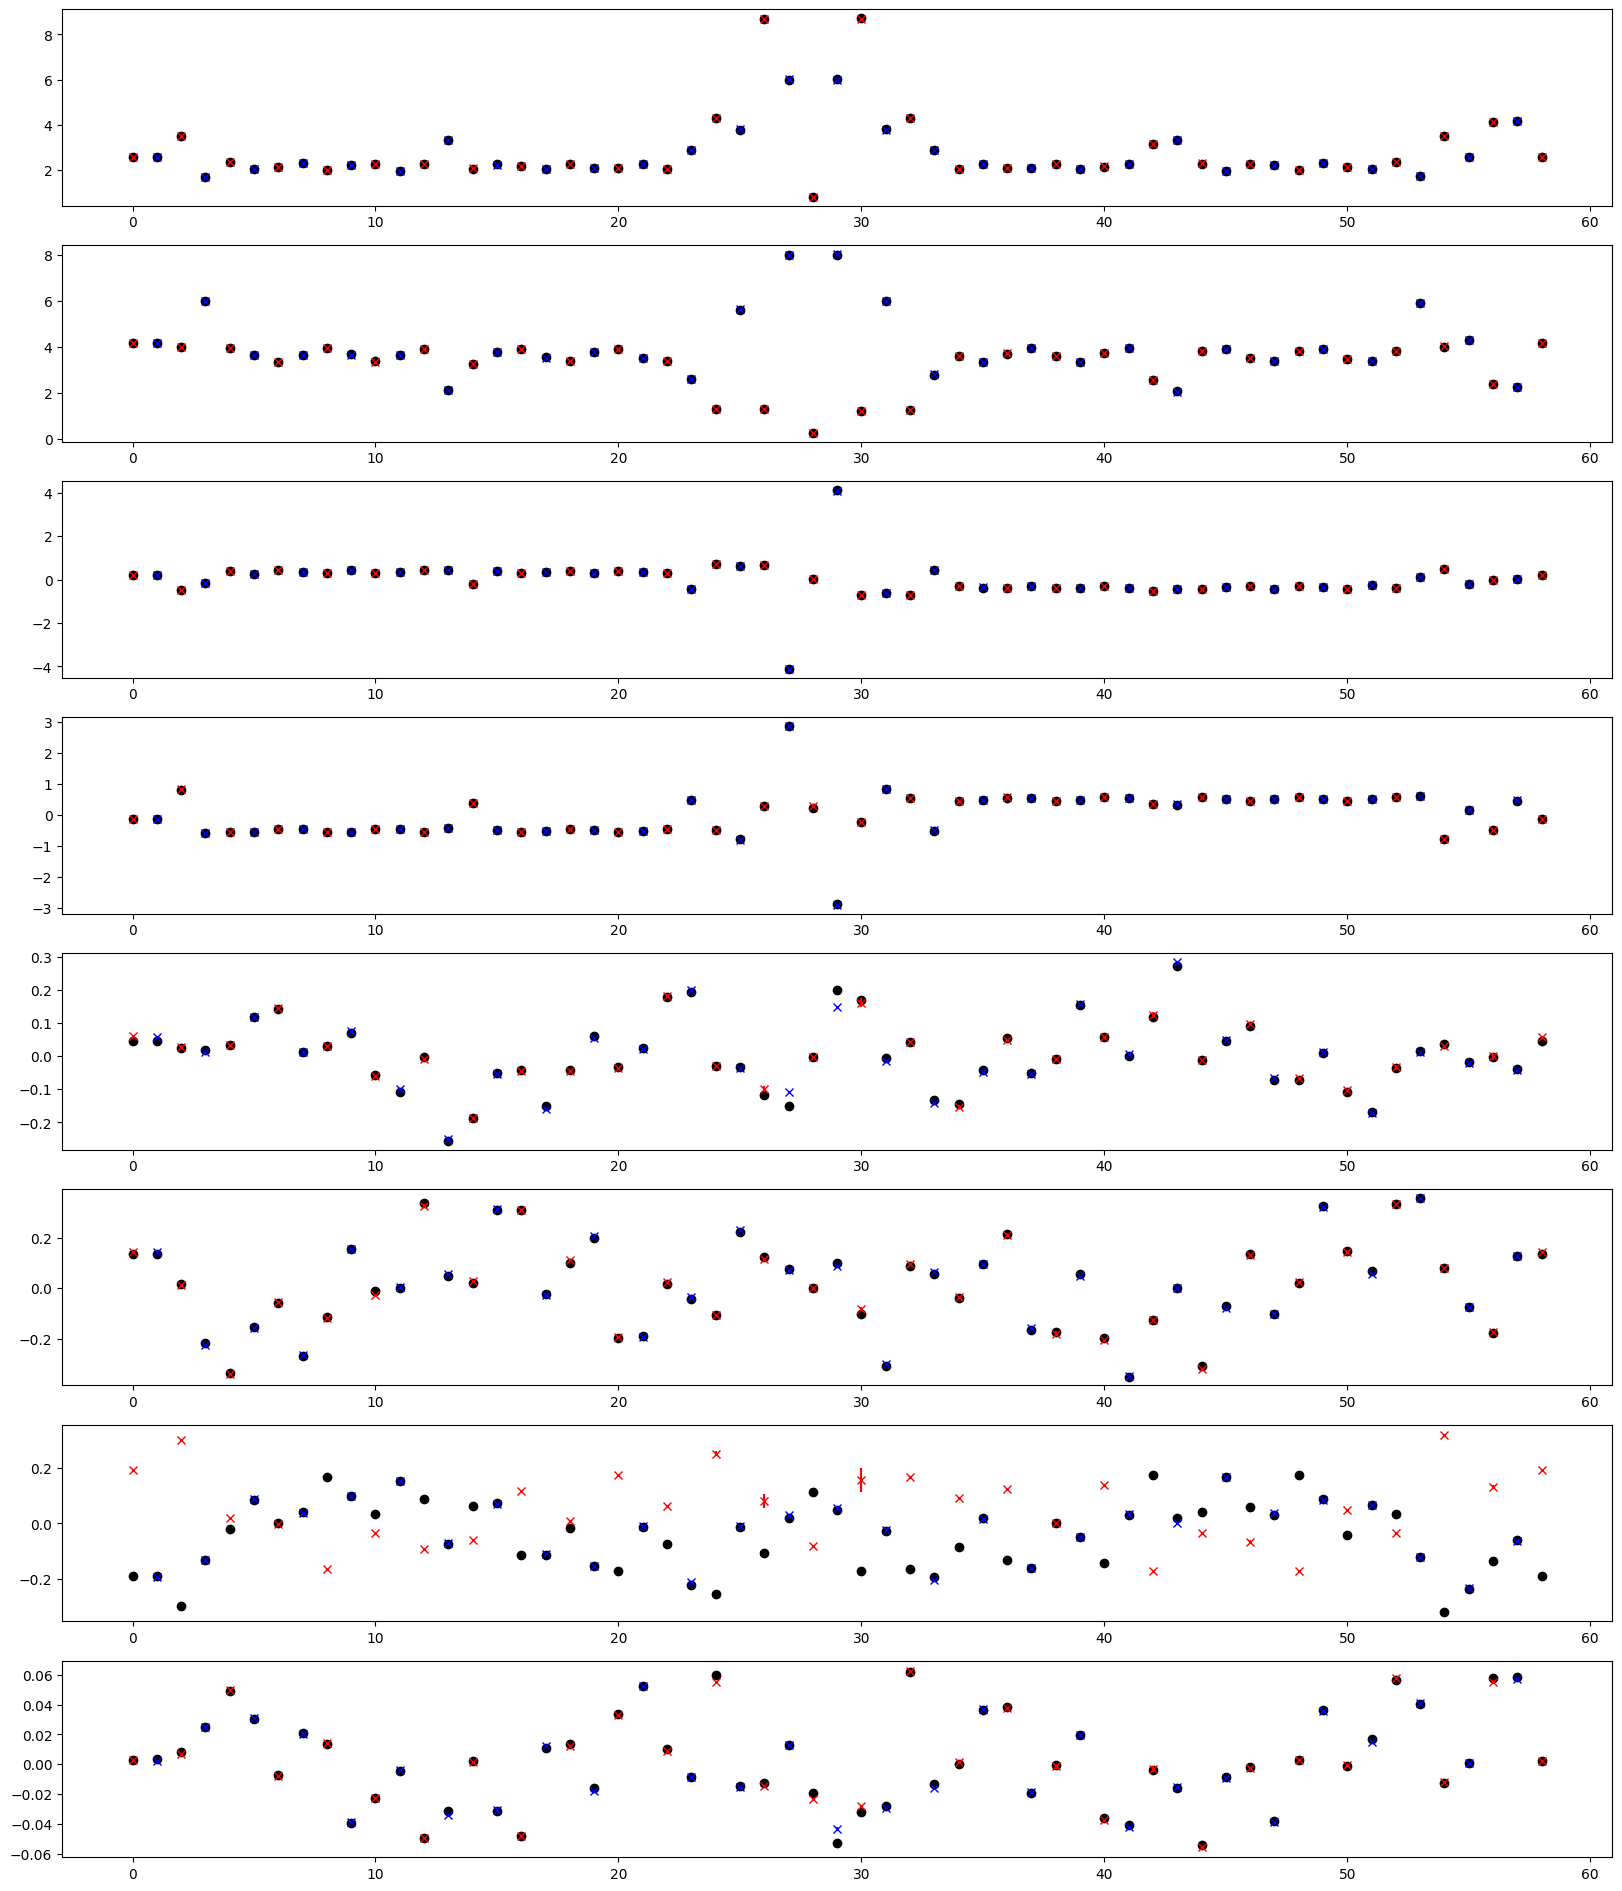

In [35]:
# Compare normalization matrix elements

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.size), N11, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n11, yerr=error_n11, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v11, yerr=error_v11, fmt=' ', color='red', marker='x')

ax = plt.subplot(812)
ax.scatter(range(model.size), N33, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n33, yerr=error_n33, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v33, yerr=error_v33, fmt=' ', color='red', marker='x')

ax = plt.subplot(813)
ax.scatter(range(model.size), N21, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n21, yerr=error_n21, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v21, yerr=error_v21, fmt=' ', color='red', marker='x')

ax = plt.subplot(814)
ax.scatter(range(model.size), N43, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n43, yerr=error_n43, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v43, yerr=error_v43, fmt=' ', color='red', marker='x')

ax = plt.subplot(815)
ax.scatter(range(model.size), N13, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n13, yerr=error_n13, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v13, yerr=error_v13, fmt=' ', color='red', marker='x')

ax = plt.subplot(816)
ax.scatter(range(model.size), N31, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n31, yerr=error_n31, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v31, yerr=error_v31, fmt=' ', color='red', marker='x')

ax = plt.subplot(817)
ax.scatter(range(model.size), N14, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n14, yerr=error_n14, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v14, yerr=error_v14, fmt=' ', color='red', marker='x')

ax = plt.subplot(818)
ax.scatter(range(model.size), N41, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n41, yerr=error_n41, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v41, yerr=error_v41, fmt=' ', color='red', marker='x')

plt.show()

# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [36]:
# Compare normalization matrix elements

print((N11[model.monitor_index] - value_n11).sum().abs())
print((N11[model.virtual_index] - value_v11).sum().abs())
print()

print((N33[model.monitor_index] - value_n33).sum().abs())
print((N33[model.virtual_index] - value_v33).sum().abs())
print()

print((N21[model.monitor_index] - value_n21).sum().abs())
print((N21[model.virtual_index] - value_v21).sum().abs())
print()

print((N43[model.monitor_index] - value_n43).sum().abs())
print((N43[model.virtual_index] - value_v43).sum().abs())
print()

print((N13[model.monitor_index] - value_n13).sum().abs())
print((N13[model.virtual_index] - value_v13).sum().abs())
print()

print((N31[model.monitor_index] - value_n31).sum().abs())
print((N31[model.virtual_index] - value_v31).sum().abs())
print()

print((N14[model.monitor_index] - value_n14).sum().abs())
print((N14[model.virtual_index] - value_v14).sum().abs())
print()

print((N41[model.monitor_index] - value_n41).sum().abs())
print((N41[model.virtual_index] - value_v41).sum().abs())
print()

tensor(7.245830231664e-02, dtype=torch.float64)
tensor(4.220997462763e-02, dtype=torch.float64)

tensor(6.143228279320e-02, dtype=torch.float64)
tensor(1.468348485870e-02, dtype=torch.float64)

tensor(2.524821957252e-02, dtype=torch.float64)
tensor(4.141364780218e-04, dtype=torch.float64)

tensor(1.418965215604e-02, dtype=torch.float64)
tensor(9.970643739128e-02, dtype=torch.float64)

tensor(1.015397300412e-02, dtype=torch.float64)
tensor(2.895891208540e-02, dtype=torch.float64)

tensor(1.394946572295e-02, dtype=torch.float64)
tensor(1.339850598949e-02, dtype=torch.float64)

tensor(3.231666328947e-03, dtype=torch.float64)
tensor(3.356844808017e+00, dtype=torch.float64)

tensor(3.120606942382e-03, dtype=torch.float64)
tensor(1.322790575805e-02, dtype=torch.float64)



In [37]:
# Twiss at virtual locations from transport (with virtual phase)

value_normal = []
error_normal = []

for virtual in model.virtual_index:
    value, error = twiss.get_twiss_virtual_coupled(virtual, limit=1, use_phase=False, bootstrap=True, count=128)
    value_normal.append(value)
    error_normal.append(error)

value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41 = torch.stack(value_normal).T
error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41 = torch.stack(error_normal).T

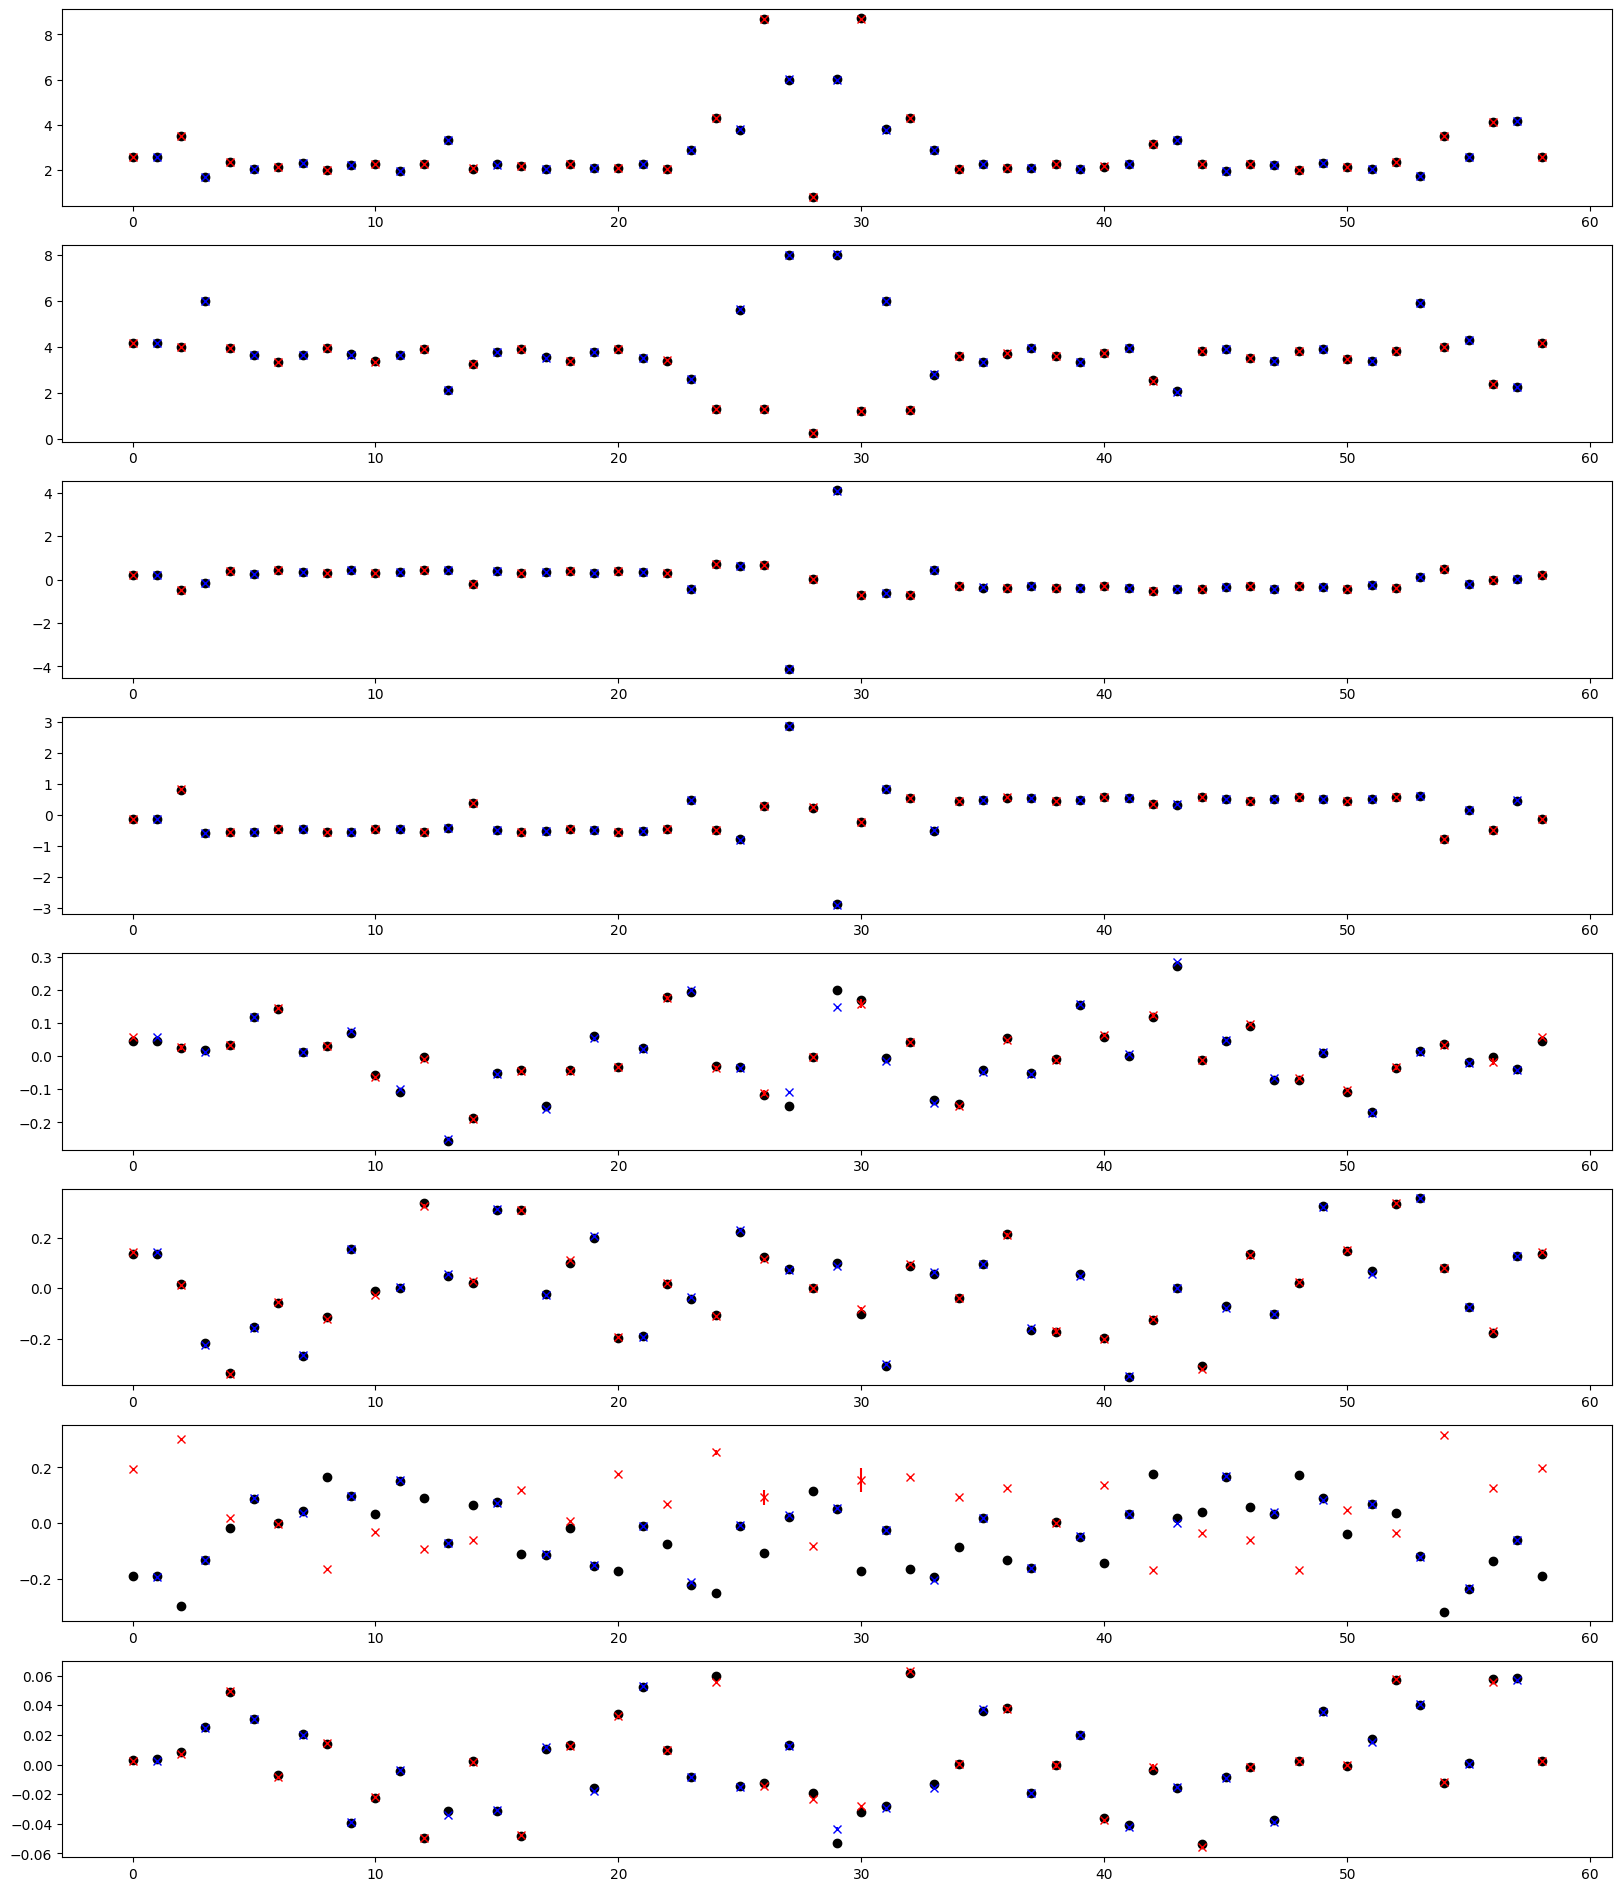

In [38]:
# Compare normalization matrix elements

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.size), N11, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n11, yerr=error_n11, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v11, yerr=error_v11, fmt=' ', color='red', marker='x')

ax = plt.subplot(812)
ax.scatter(range(model.size), N33, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n33, yerr=error_n33, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v33, yerr=error_v33, fmt=' ', color='red', marker='x')

ax = plt.subplot(813)
ax.scatter(range(model.size), N21, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n21, yerr=error_n21, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v21, yerr=error_v21, fmt=' ', color='red', marker='x')

ax = plt.subplot(814)
ax.scatter(range(model.size), N43, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n43, yerr=error_n43, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v43, yerr=error_v43, fmt=' ', color='red', marker='x')

ax = plt.subplot(815)
ax.scatter(range(model.size), N13, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n13, yerr=error_n13, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v13, yerr=error_v13, fmt=' ', color='red', marker='x')

ax = plt.subplot(816)
ax.scatter(range(model.size), N31, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n31, yerr=error_n31, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v31, yerr=error_v31, fmt=' ', color='red', marker='x')

ax = plt.subplot(817)
ax.scatter(range(model.size), N14, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n14, yerr=error_n14, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v14, yerr=error_v14, fmt=' ', color='red', marker='x')

ax = plt.subplot(818)
ax.scatter(range(model.size), N41, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n41, yerr=error_n41, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v41, yerr=error_v41, fmt=' ', color='red', marker='x')

plt.show()

# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [39]:
# Compare normalization matrix elements

print((N11[model.monitor_index] - value_n11).sum().abs())
print((N11[model.virtual_index] - value_v11).sum().abs())
print()

print((N33[model.monitor_index] - value_n33).sum().abs())
print((N33[model.virtual_index] - value_v33).sum().abs())
print()

print((N21[model.monitor_index] - value_n21).sum().abs())
print((N21[model.virtual_index] - value_v21).sum().abs())
print()

print((N43[model.monitor_index] - value_n43).sum().abs())
print((N43[model.virtual_index] - value_v43).sum().abs())
print()

print((N13[model.monitor_index] - value_n13).sum().abs())
print((N13[model.virtual_index] - value_v13).sum().abs())
print()

print((N31[model.monitor_index] - value_n31).sum().abs())
print((N31[model.virtual_index] - value_v31).sum().abs())
print()

print((N14[model.monitor_index] - value_n14).sum().abs())
print((N14[model.virtual_index] - value_v14).sum().abs())
print()

print((N41[model.monitor_index] - value_n41).sum().abs())
print((N41[model.virtual_index] - value_v41).sum().abs())
print()

tensor(7.245830231664e-02, dtype=torch.float64)
tensor(1.286826145690e-02, dtype=torch.float64)

tensor(6.143228279320e-02, dtype=torch.float64)
tensor(2.844456636653e-02, dtype=torch.float64)

tensor(2.524821957252e-02, dtype=torch.float64)
tensor(7.971550359980e-03, dtype=torch.float64)

tensor(1.418965215604e-02, dtype=torch.float64)
tensor(6.524399674509e-02, dtype=torch.float64)

tensor(1.015397300412e-02, dtype=torch.float64)
tensor(3.802645615978e-03, dtype=torch.float64)

tensor(1.394946572295e-02, dtype=torch.float64)
tensor(2.849275517949e-02, dtype=torch.float64)

tensor(3.231666328947e-03, dtype=torch.float64)
tensor(3.351680845315e+00, dtype=torch.float64)

tensor(3.120606942382e-03, dtype=torch.float64)
tensor(8.386570582074e-03, dtype=torch.float64)



In [40]:
# Transport matrix between locations

probe = 10
other = 40

print(model.is_monitor(probe))
print(model.is_monitor(other))

numpy.set_printoptions(linewidth=160, formatter = {'all': lambda x: f'{x:.12f}'})

# Model matrix

print(model.matrix(probe, other).cpu().numpy())
print()

# Matrix with errors

print(model.map_transport_matrix(probe, other).cpu().numpy())
print()

# Matrix (uncoupled, uses twiss.ax, twiss.bx, twiss.ay, twiss.by)

model.model = 'uncoupled'
print(twiss.matrix(probe, other).cpu().numpy())
print()

# Matrix (coupled, uses twiss.normal)

model.model = 'coupled'
print(twiss.matrix(probe, other).cpu().numpy())
print()

False
False
[[-1.101981284744 4.291362513504 0.000000000000 0.000000000000]
 [0.061607262265 -1.147368937519 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -2.087765916041 -12.316964538171]
 [0.000000000000 0.000000000000 -0.273200163375 -2.090750064735]]

[[-1.070806256158 4.174067810126 -0.012763912922 -0.028085405744]
 [0.051081945954 -1.133324127040 0.005854867986 0.040386952682]
 [-0.014481286794 0.150327936859 -1.994063513245 -12.263504617943]
 [0.000946865515 0.014413005411 -0.257526408868 -2.085453816281]]

[[-1.073127595342 4.484358041370 0.000000000000 0.000000000000]
 [0.053269905165 -1.154458549911 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -2.025647896496 -11.827224283798]
 [0.000000000000 0.000000000000 -0.252012303255 -1.965102641856]]

[[-0.957254413665 4.581408526599 -0.004522664007 -0.048378260986]
 [-0.008846963886 -1.002208825156 0.005841275674 0.040455766164]
 [-0.012907208316 0.014968034904 -2.033823264547 -11.848736906676]
 [0.

In [41]:
# Transport matrix between locations

probe = 11
other = 40

print(model.is_monitor(probe))
print(model.is_monitor(other))

numpy.set_printoptions(linewidth=160, formatter = {'all': lambda x: f'{x:.12f}'})

# Model matrix

print(model.matrix(probe, other).cpu().numpy())
print()

# Matrix with errors

print(model.map_transport_matrix(probe, other).cpu().numpy())
print()

# Matrix (uncoupled, uses twiss.ax, twiss.bx, twiss.ay, twiss.by)

model.model = 'uncoupled'
print(twiss.matrix(probe, other).cpu().numpy())
print()

# Matrix (coupled, uses twiss.normal)

model.model = 'coupled'
print(twiss.matrix(probe, other).cpu().numpy())
print()

True
False
[[0.101101748385 3.468613345653 0.000000000000 0.000000000000]
 [-0.287210118351 0.037379674852 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -1.627344339367 -5.054851581057]
 [0.000000000000 0.000000000000 -0.325785214149 -1.626451047143]]

[[0.102466683883 3.359456347251 -0.001762100259 0.018675016418]
 [-0.295288803529 0.079869946085 0.006748644560 0.038489726424]
 [0.014838341993 0.079636500709 -1.675837695943 -5.897722054989]
 [0.002862071256 0.002296182066 -0.334777945796 -1.775005500503]]

[[0.254221574100 3.044551394758 0.000000000000 0.000000000000]
 [-0.321177881445 0.087157957225 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -1.560407588487 -4.717342658907]
 [0.000000000000 0.000000000000 -0.310804598534 -1.580466417520]]

[[0.249949446148 3.050583032703 -0.006960795650 -0.032508658496]
 [-0.311373990376 0.200620246826 0.006322824059 0.031990304530]
 [-0.000547500909 0.064832452088 -1.560481013642 -4.719878809868]
 [0.000261158128

In [42]:
# Transport matrix between locations

probe = 11
other = 41

print(model.is_monitor(probe))
print(model.is_monitor(other))

numpy.set_printoptions(linewidth=160, formatter = {'all': lambda x: f'{x:.12f}'})

# Model matrix

print(model.matrix(probe, other).cpu().numpy())
print()

# Matrix with errors

print(model.map_transport_matrix(probe, other).cpu().numpy())
print()

# Matrix (uncoupled, uses twiss.ax, twiss.bx, twiss.ay, twiss.by)

model.model = 'uncoupled'
print(twiss.matrix(probe, other).cpu().numpy())
print()

# Matrix (coupled, uses twiss.normal)

model.model = 'coupled'
print(twiss.matrix(probe, other).cpu().numpy())
print()

True
True
[[-1.076221857754 4.027541089140 0.000000000000 0.000000000000]
 [0.041836114257 -1.085739581259 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -2.090204875407 -12.308509966242]
 [0.000000000000 0.000000000000 -0.272989728269 -2.085966233446]]

[[-1.108572369668 4.078966553580 0.028023185370 0.187417607964]
 [0.043569362677 -1.062559490840 -0.001301279223 -0.016058209836]
 [0.017771828630 -0.036082136990 -2.148485420971 -13.209524862730]
 [0.002214911750 -0.016095040459 -0.280236523385 -2.188517267448]]

[[-1.099761496481 4.078432978232 0.000000000000 0.000000000000]
 [0.041396743102 -1.062806659441 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -2.124615274378 -13.046443701460]
 [0.000000000000 0.000000000000 -0.277599971382 -2.175307903458]]

[[-1.107619353443 4.074946729656 0.025424424265 0.176999516744]
 [0.043853358513 -1.064472718574 0.000663333886 -0.008380707742]
 [0.027610220375 -0.061410273508 -2.143142706112 -13.170180375300]
 [0.004